# TPC raw ADC → IBF and primary-density maps

This notebook starts from the native per-sector/per-module histograms produced by
`PHGarfieldRawHitsQA`:

`h_adc_pad_vs_layer_side{side}_sec{sector:02d}_R{module}_{QA_NAME}`

It is intentionally split into two independent parts.

## Part I — IBF
1. Load native `pad × layer` maps.
2. Detect vertical dead FEE regions wider than a configurable number of pads.
3. Detect full- and half-sector dead horizontal stripes.
4. Repair only **inside each sector**; sector gaps are never bridged.
5. Optionally suppress SAMPA/pad outliers using raw, sum, mean, median, or trimmed mean.
6. Convert cleaned ADC to an areal-density proxy using `r*dphi*dr`.
7. Smoothly extrapolate R1 inward to the 21 cm inner field cage.
8. Build side-0 and side-1 `rho(r,phi)` maps and diagnostic 2D fits.

## Part II — primary density
Starts again from the cleaned ADC map, optionally divides by a gain map, and makes
the same `r`, `phi`, and 2D-fit diagnostics.

For now `N_EVENTS = 1`. The absolute IBF scale is deliberately left free for later
PHGarfield/data tuning with distortion observables such as rDCA.


In [1]:
import ROOT as root
import numpy as np
import math
from array import array
from pathlib import Path
import matplotlib.pyplot as plt

from scipy import ndimage
from scipy.optimize import least_squares

root.gROOT.SetBatch(True)
root.TH1.AddDirectory(False)

# ============================================================
# USER CONFIGURATION
# ============================================================

INPUT_ROOT = "input/tpc_poly_track_HITS_ppFieldOn_795130_qa.root"
QA_NAME = "PHGarfieldRawHitsQA"
N_EVENTS = 1.0

OUTPUT_DIR = Path("output")
QA_PLOT_DIR = OUTPUT_DIR / "qa_plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
QA_PLOT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_ROOT = OUTPUT_DIR / "TPC_IBF_primary_maps.root"
QA_ROOT = OUTPUT_DIR / "TPC_IBF_primary_QA.root"

N_SIDES = 2
N_SECTORS = 12
N_MODULES = 3
LAYERS_PER_MODULE = 16
N_PADS = [94, 128, 192]

MIN_RADII_MODULE_MM = [314.9835971194212, 416.5920253621078, 589.1096334932404]
DELTA_RADII_MODULE_MM = [5.657908935192669, 10.206891263554285, 10.970474549405283]
AVR_DPHI_MODULE = [0.005307305707805798, 0.003959159565794228, 0.0026514278029726376]
AVR_MINPHI_MODULE = [1.3219316149976348, 1.3179398673058638, 1.3175593270455]

USE_IDEAL_PAD_MAP = True
IDEAL_PAD_MAP_LIBRARY = "libtpctrackreco.so"

IFC_RADIUS_CM = 21.0

# ------------------------------------------------------------------
# DEAD AREA DETECTION
# ------------------------------------------------------------------
DEAD_CELL_REL_THRESHOLD = 0.18

# Set to 1 if you want essentially every >=2-pad-wide vertical zero region
# to be considered. Width must be STRICTLY larger than this.
MIN_DEAD_FEE_WIDTH = 1
DEAD_FEE_LAYER_FRACTION = 0.55

MIN_DEAD_BLOCK_WIDTH = 2
MIN_DEAD_BLOCK_LAYERS = 2
MIN_DEAD_BLOCK_CELLS = 6

FULL_STRIPE_FRACTION = 0.72
HALF_STRIPE_FRACTION = 0.72
OTHER_HALF_MAX_DEAD_FRACTION = 0.35

DEAD_STRIPE_MODE = "neighbor"
FEE_CONTEXT_PADS = 12
BLOCK_CONTEXT_PADS = 12
BLOCK_CONTEXT_LAYERS = 3
STRIPE_NEIGHBOR_LAYERS = 3

# Last-pass cleanup of isolated/remaining near-zero cells AFTER the main repair.
# This is deliberately conservative and works only inside native sector maps.
REPAIR_RESIDUAL_ZEROS = True
RESIDUAL_ZERO_REL_THRESHOLD = 0.06
RESIDUAL_ZERO_MIN_NEIGHBORS = 4
RESIDUAL_ZERO_MAX_PASSES = 2

# ------------------------------------------------------------------
# PAD/SAMPA ESTIMATOR
# ------------------------------------------------------------------
# "raw", "sum", "mean", "median", "trimmed_mean"
ADC_ESTIMATOR = "trimmed_mean"
TRIM_FRACTION = 0.15
CLIP_OUTLIERS = True
CLIP_NSIGMA = 5.0

GLOBAL_PHI_BINS = 720
PHI_MIN = -math.pi
PHI_MAX = math.pi

# ------------------------------------------------------------------
# SAFE POWER-LAW EXTRAPOLATION TO 21 cm
# rho(r,phi) = A(phi)/r^alpha
# Used independently for IBF and primary.
# ------------------------------------------------------------------
ALPHA_INITIAL = 1.5
ALPHA_BOUNDS = (0.8, 2.7)
N_R1_FIT_LAYERS = 10
N_INNER_EXTRAP_BINS = 24

ALPHA_LOSS = "soft_l1"
ALPHA_F_SCALE = 1.0
MIN_PHI_BINS_PER_R_LAYER = 30
MIN_HEALTHY_FRACTION_FOR_ALPHA = 0.35

N_R1_AMPLITUDE_LAYERS = 8
MIN_POINTS_FOR_PHI_AMPLITUDE = 2
MIN_R1_COVERAGE_LAYERS = 2

# Save three inward phi models:
#   binwise: current robust A(phi) independently per fine phi bin
#   lowharmonic: broad smooth phi modulation, n=0..LOW_PHI_HARMONIC
#   sector12: same broad modulation plus explicit n=12 sector structure
LOW_PHI_HARMONIC = 4
IBF_EXTRAPOLATION_FINAL = "sector12"

# ------------------------------------------------------------------
# Smooth diagnostic 2D fit
# ------------------------------------------------------------------
FOURIER_ORDER = 12
RADIAL_POLY_ORDER = 3
FIT_MIN_DENSITY = 0.0
ROBUST_2D_FIT = True
ROBUST_2D_LOSS = "soft_l1"

# ------------------------------------------------------------------
# Gain map / primary density
# ------------------------------------------------------------------
GAIN_MAP_FILE = "../distort/input/layer_gain_79513_Mariia_side01.root"

GAIN_MAP_HIST_SIDE0 = "hGainMap_side0_South"
GAIN_MAP_HIST_SIDE1 = "hGainMap_side1_North"

# Gain histogram axes from the supplied ROOT file:
# x = sector 0..11, y = TPC layer index 0..47.
# Raw-hit TPC layers are 7..54.
GAIN_LAYER_OFFSET = 7

PRIMARY_DIVIDE_BY_GAIN = True

print("Configuration loaded")
print("Input:", INPUT_ROOT)
print("Gain map:", GAIN_MAP_FILE)
print("Output ROOT:", OUTPUT_ROOT)
print("QA ROOT:", QA_ROOT)


Welcome to JupyROOT 6.30/06
Configuration loaded
Input: input/tpc_poly_track_HITS_ppFieldOn_795130_qa.root
Gain map: ../distort/input/layer_gain_79513_Mariia_side01.root
Output ROOT: output/TPC_IBF_primary_maps.root
QA ROOT: output/TPC_IBF_primary_QA.root


## Geometry and ROOT helpers

Dead-region finding is performed in native sector coordinates. The conversion to
global `(r,phi)` happens only after repair.

This version first tries to load the same `IdealPadMap` used by
`PHGarfieldRawHitsQA`. If available, it uses exact `get_radius(layer)` and
`get_phi(side,sector,layer,local_pad)` values. This is especially important for
the sector that crosses `phi = +/-pi`: its pad centers are unwrapped only while
calculating `dphi`, then wrapped back to `[-pi,pi)` for histogram filling.

The supplied average geometry is retained only as a fallback.


In [2]:
def get_hist_name(side, sector, module):
    return f"h_adc_pad_vs_layer_side{side}_sec{sector:02d}_R{module+1}_{QA_NAME}"

def th2_to_numpy(h):
    nx, ny = h.GetNbinsX(), h.GetNbinsY()
    z = np.empty((ny, nx), dtype=float)
    for iy in range(ny):
        for ix in range(nx):
            z[iy, ix] = h.GetBinContent(ix+1, iy+1)
    x = np.array([h.GetXaxis().GetBinCenter(i+1) for i in range(nx)])
    y = np.array([h.GetYaxis().GetBinCenter(i+1) for i in range(ny)])
    return z, x, y

# ------------------------------------------------------------
# Exact IdealPadMap geometry when available
# ------------------------------------------------------------
ideal_pad_map = None

if USE_IDEAL_PAD_MAP:
    try:
        root.gSystem.Load(IDEAL_PAD_MAP_LIBRARY)
        if hasattr(root, "IdealPadMap"):
            ideal_pad_map = root.IdealPadMap()
            if (not ideal_pad_map.is_loaded()) and ideal_pad_map.load_from_cdb(0) != 0:
                print("WARNING: IdealPadMap CDB load failed; using fallback geometry")
                ideal_pad_map = None
        else:
            print("WARNING: ROOT.IdealPadMap is unavailable; using fallback geometry")
    except Exception as exc:
        print("WARNING: could not initialize IdealPadMap:", exc)
        ideal_pad_map = None

print("Geometry source:", "IdealPadMap" if ideal_pad_map is not None else "fallback averages")

def global_layer(module, local_layer):
    return 7 + 16*module + local_layer

def module_layer_radii_cm(module):
    if ideal_pad_map is not None:
        return np.array([
            float(ideal_pad_map.get_radius(global_layer(module, il)))
            for il in range(LAYERS_PER_MODULE)
        ])
    r0 = MIN_RADII_MODULE_MM[module] / 10.0
    dr = DELTA_RADII_MODULE_MM[module] / 10.0
    return r0 + dr*(np.arange(LAYERS_PER_MODULE)+0.5)

def module_layer_dr_cm(module):
    r = module_layer_radii_cm(module)
    # Voronoi-like radial width around layer centers, bounded by midpoint.
    e = np.empty(len(r)+1)
    e[1:-1] = 0.5*(r[:-1]+r[1:])
    e[0] = r[0] - 0.5*(r[1]-r[0])
    e[-1] = r[-1] + 0.5*(r[-1]-r[-2])
    return np.diff(e)

def wrap_phi(phi):
    return (phi + np.pi) % (2*np.pi) - np.pi

def sector_phi_centers(module, sector, local_layer, side=0):
    npads = N_PADS[module]

    if ideal_pad_map is not None:
        layer = global_layer(module, local_layer)
        vals = [
            float(ideal_pad_map.get_phi(side, sector, layer, local_pad))
            for local_pad in range(npads)
        ]
        return np.array([wrap_phi(v) for v in vals], dtype=float)

    dphi = AVR_DPHI_MODULE[module]
    sector_pitch = 2*np.pi/12.0
    phi0 = AVR_MINPHI_MODULE[module] + sector*sector_pitch
    return wrap_phi(phi0 + (np.arange(npads)+0.5)*dphi)

def layer_dphi(module, local_layer, side=0, sector=0):
    ph = sector_phi_centers(module, sector, local_layer, side)
    # unwrap before taking differences; this is important for the sector
    # that crosses +/-pi.
    pu = np.unwrap(ph)
    if len(pu) < 2:
        return AVR_DPHI_MODULE[module]
    return float(np.median(np.abs(np.diff(pu))))

def pad_area_cm2(module, local_layer, side=0):
    r = module_layer_radii_cm(module)[local_layer]
    dr = module_layer_dr_cm(module)[local_layer]
    dphi = layer_dphi(module, local_layer, side)
    return r * dphi * dr

def robust_scale(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 0.0
    med = np.median(x)
    mad = np.median(np.abs(x-med))
    return 1.4826*mad if mad > 0 else np.std(x)

def clipped_values(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return x
    med = np.median(x)
    sig = robust_scale(x)
    if sig <= 0 or not np.isfinite(sig):
        return x
    return x[np.abs(x-med) <= CLIP_NSIGMA*sig]

def estimate_values(x, mode=None):
    if mode is None:
        mode = ADC_ESTIMATOR
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan

    if mode == "sum":
        return np.sum(x)
    if mode == "raw":
        return np.mean(x)

    if CLIP_OUTLIERS:
        xc = clipped_values(x)
        if xc.size:
            x = xc

    if mode == "mean":
        return np.mean(x)
    if mode == "median":
        return np.median(x)
    if mode == "trimmed_mean":
        xs = np.sort(x)
        ntrim = int(TRIM_FRACTION*len(xs))
        if 2*ntrim >= len(xs):
            return np.median(xs)
        return np.mean(xs[ntrim:len(xs)-ntrim])

    raise ValueError(mode)

def weighted_median(values, weights):
    values = np.asarray(values, float)
    weights = np.asarray(weights, float)
    good = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not np.any(good):
        return np.nan
    v = values[good]
    w = weights[good]
    order = np.argsort(v)
    v = v[order]
    w = w[order]
    c = np.cumsum(w)
    return v[np.searchsorted(c, 0.5*c[-1])]


Geometry source: fallback averages


Error in <TUnixSystem::FindDynamicLibrary>: libtpctrackreco.so does not exist in /home/yoren/bnl/ROOT/install/lib:.:/home/yoren/bnl/ROOT/install/lib:/lib/x86_64-linux-gnu/glibc-hwcaps/x86-64-v3:/lib/x86_64-linux-gnu/glibc-hwcaps/x86-64-v2:/lib/x86_64-linux-gnu/tls/haswell/x86_64:/lib/x86_64-linux-gnu/tls/haswell:/lib/x86_64-linux-gnu/tls/x86_64:/lib/x86_64-linux-gnu/tls:/lib/x86_64-linux-gnu/haswell/x86_64:/lib/x86_64-linux-gnu/haswell:/lib/x86_64-linux-gnu/x86_64:/lib/x86_64-linux-gnu:/usr/lib/x86_64-linux-gnu/glibc-hwcaps/x86-64-v3:/usr/lib/x86_64-linux-gnu/glibc-hwcaps/x86-64-v2:/usr/lib/x86_64-linux-gnu/tls/haswell/x86_64:/usr/lib/x86_64-linux-gnu/tls/haswell:/usr/lib/x86_64-linux-gnu/tls/x86_64:/usr/lib/x86_64-linux-gnu/tls:/usr/lib/x86_64-linux-gnu/haswell/x86_64:/usr/lib/x86_64-linux-gnu/haswell:/usr/lib/x86_64-linux-gnu/x86_64:/usr/lib/x86_64-linux-gnu:/lib/glibc-hwcaps/x86-64-v3:/lib/glibc-hwcaps/x86-64-v2:/lib/tls/haswell/x86_64:/lib/tls/haswell:/lib/tls/x86_64:/lib/tls:/lib/

# Part I — IBF source shape

## 1. Load native sector/module maps

In [3]:
fin = root.TFile.Open(INPUT_ROOT, "READ")
if not fin or fin.IsZombie():
    raise OSError(f"Cannot open {INPUT_ROOT}")

raw_maps = {}
missing = []

for side in range(N_SIDES):
    for module in range(N_MODULES):
        for sector in range(N_SECTORS):
            name = get_hist_name(side, sector, module)
            h = fin.Get(name)
            if not h:
                missing.append(name)
                continue
            z, pads, layers = th2_to_numpy(h)
            raw_maps[(side,module,sector)] = {
                "adc": z/N_EVENTS,
                "pads": pads,
                "layers": layers,
                "name": name,
            }

print(f"Loaded {len(raw_maps)} maps")
if missing:
    print(f"Missing {len(missing)} histograms")
    print("\n".join(missing[:10]))


Loaded 72 maps


## 2. Automatic dead FEE / stripe / block masks

The original version missed exactly-zero full horizontal stripes because its
reference was calculated from the same dead row. This version uses a 2D robust
dead-cell reference:

- vertical structures are compared with the healthy behavior of their **row**;
- horizontal structures are compared with the healthy behavior of their **column**.

It then classifies:

- full-height vertical FEEs wider than `MIN_DEAD_FEE_WIDTH`;
- full-sector horizontal stripes;
- half-sector horizontal stripes;
- large connected rectangular dead blocks that do not match either ideal shape.

Everything is still analyzed **inside one sector at a time**, so sector gaps are
never filled across.


In [4]:
def contiguous_true_regions(mask):
    mask = np.asarray(mask, bool)
    regions = []
    start = None
    for i, v in enumerate(mask):
        if v and start is None:
            start = i
        elif (not v) and start is not None:
            regions.append((start, i))
            start = None
    if start is not None:
        regions.append((start, len(mask)))
    return regions

def robust_dead_cell_candidates(adc):
    """
    Catch both vertical and horizontal dead structures.

    The reference for each cell is the larger of:
      - robust median of its radial layer (across phi/pads)
      - robust median of its pad column (across layers)

    Therefore:
      * a vertical FEE is low compared with the row reference;
      * a horizontal stripe is low compared with the column reference.

    The threshold is deliberately conservative so real physics variations
    are not classified as dead.
    """
    adc = np.asarray(adc, float)
    nlayer, npad = adc.shape

    pos = np.where(adc > 0, adc, np.nan)
    row_ref = np.nanmedian(pos, axis=1)
    col_ref = np.nanmedian(pos, axis=0)

    # If an entire row/column is dead, nanmedian can be nan.
    global_ref = np.nanmedian(pos)
    row_ref = np.where(np.isfinite(row_ref), row_ref, global_ref)
    col_ref = np.where(np.isfinite(col_ref), col_ref, global_ref)

    expected = np.maximum(row_ref[:, None], col_ref[None, :])
    candidate = np.isfinite(expected) & (expected > 0) & (
        adc < DEAD_CELL_REL_THRESHOLD*expected
    )
    return candidate, expected

def detect_dead_structures(adc):
    candidate, expected = robust_dead_cell_candidates(adc)
    nlayer, npad = adc.shape
    mid = npad//2

    # ---- vertical FEE ----
    col_dead_fraction = np.mean(candidate, axis=0)
    dead_fee_cols = col_dead_fraction >= DEAD_FEE_LAYER_FRACTION

    fee_mask = np.zeros_like(candidate)
    fee_regions = []
    for lo, hi in contiguous_true_regions(dead_fee_cols):
        if (hi-lo) > MIN_DEAD_FEE_WIDTH:
            fee_mask[:, lo:hi] = True
            fee_regions.append((lo, hi))

    # ---- horizontal stripes ----
    stripe_half = np.zeros_like(candidate)
    stripe_full = np.zeros_like(candidate)
    stripe_details = []

    for il in range(nlayer):
        usable = ~fee_mask[il]
        if np.count_nonzero(usable) < 4:
            continue

        dead = candidate[il] & usable
        frac = np.count_nonzero(dead)/np.count_nonzero(usable)

        # IMPORTANT: this works even if the entire row is exactly zero.
        if frac >= FULL_STRIPE_FRACTION:
            stripe_full[il, usable] = True
            stripe_details.append(("full", il, frac))
            continue

        left_use = usable[:mid]
        right_use = usable[mid:]
        lf = np.count_nonzero(dead[:mid])/max(np.count_nonzero(left_use), 1)
        rf = np.count_nonzero(dead[mid:])/max(np.count_nonzero(right_use), 1)

        if lf >= HALF_STRIPE_FRACTION and rf <= OTHER_HALF_MAX_DEAD_FRACTION:
            stripe_half[il, :mid] = dead[:mid]
            stripe_details.append(("half-left", il, lf))
        elif rf >= HALF_STRIPE_FRACTION and lf <= OTHER_HALF_MAX_DEAD_FRACTION:
            stripe_half[il, mid:] = dead[mid:]
            stripe_details.append(("half-right", il, rf))

    # ---- arbitrary large rectangular dead blocks ----
    # Connected-component analysis catches cases like the large blocks in the
    # supplied plot that are not a perfect FEE or perfect stripe.
    already = fee_mask | stripe_half | stripe_full
    remaining = candidate & ~already

    labels, nlab = ndimage.label(remaining, structure=np.ones((3,3), dtype=int))
    block_mask = np.zeros_like(candidate)
    block_details = []

    for lab in range(1, nlab+1):
        yy, xx = np.where(labels == lab)
        if len(xx) == 0:
            continue
        width = xx.max()-xx.min()+1
        height = yy.max()-yy.min()+1
        ncells = len(xx)

        if (width >= MIN_DEAD_BLOCK_WIDTH and
            height >= MIN_DEAD_BLOCK_LAYERS and
            ncells >= MIN_DEAD_BLOCK_CELLS):
            block_mask[yy, xx] = True
            block_details.append(
                (int(yy.min()), int(yy.max()+1),
                 int(xx.min()), int(xx.max()+1), int(ncells))
            )

    return {
        "candidate": candidate,
        "expected": expected,
        "fee": fee_mask,
        "stripe_half": stripe_half,
        "stripe_full": stripe_full,
        "block": block_mask,
        "fee_regions": fee_regions,
        "stripe_details": stripe_details,
        "block_details": block_details,
        "col_dead_fraction": col_dead_fraction,
    }

auto_masks = {}
for key, item in raw_maps.items():
    auto_masks[key] = detect_dead_structures(item["adc"])

print("Dead-FEE regions:",
      sum(len(v["fee_regions"]) for v in auto_masks.values()))
print("Stripe candidates:",
      sum(len(v["stripe_details"]) for v in auto_masks.values()))
print("Large dead blocks:",
      sum(len(v["block_details"]) for v in auto_masks.values()))


/tmp/ipykernel_9114/1283937833.py:35: RuntimeWarning: All-NaN slice encountered
  col_ref = np.nanmedian(pos, axis=0)


Dead-FEE regions: 37
Stripe candidates: 78
Large dead blocks: 108


### Optional manual corrections

In [5]:
# Zero-based side/module/sector/local-layer/local-pad indices.
MANUAL_DEAD_FEE = [
    # (side, module, sector, first_pad, last_pad_exclusive)
]
MANUAL_FULL_STRIPE = [
    # (side, module, sector, local_layer)
]
MANUAL_HALF_STRIPE = [
    # (side, module, sector, local_layer, "left" or "right")
]
MANUAL_DEAD_BLOCK = [
    # (side, module, sector, layer_lo, layer_hi, pad_lo, pad_hi)
]

for side,module,sector,lo,hi in MANUAL_DEAD_FEE:
    key=(side,module,sector)
    auto_masks[key]["fee"][:,lo:hi] = True
    auto_masks[key]["fee_regions"].append((lo,hi))

for side,module,sector,il in MANUAL_FULL_STRIPE:
    key=(side,module,sector)
    valid=~auto_masks[key]["fee"][il]
    auto_masks[key]["stripe_full"][il,valid]=True

for side,module,sector,il,which in MANUAL_HALF_STRIPE:
    key=(side,module,sector)
    npad=raw_maps[key]["adc"].shape[1]
    mid=npad//2
    if which=="left":
        auto_masks[key]["stripe_half"][il,:mid]=True
    elif which=="right":
        auto_masks[key]["stripe_half"][il,mid:]=True
    else:
        raise ValueError(which)

for side,module,sector,l0,l1,p0,p1 in MANUAL_DEAD_BLOCK:
    key=(side,module,sector)
    auto_masks[key]["block"][l0:l1,p0:p1]=True


## 3. Repair

1. Dead FEE gaps are interpolated from healthy pads on their immediate left/right,
   within the same sector only.
2. Half-sector stripes are estimated from the healthy half of the same layer.
3. Full-sector stripes are either set to zero or estimated from neighboring radial
   layers according to `DEAD_STRIPE_MODE`.


In [6]:
def good_context_values(arr, mask):
    x = arr[~mask]
    x = x[np.isfinite(x) & (x > 0)]
    return x

def repair_fee_regions(adc, fee_regions, all_dead_mask):
    out = adc.copy().astype(float)
    nlayer, npad = out.shape

    for lo, hi in fee_regions:
        left_idx = np.arange(max(0,lo-FEE_CONTEXT_PADS), lo)
        right_idx = np.arange(hi, min(npad,hi+FEE_CONTEXT_PADS))

        for il in range(nlayer):
            left = out[il,left_idx] if left_idx.size else np.array([])
            right = out[il,right_idx] if right_idx.size else np.array([])

            if left_idx.size:
                left = left[~all_dead_mask[il,left_idx]]
            if right_idx.size:
                right = right[~all_dead_mask[il,right_idx]]

            left = left[np.isfinite(left) & (left>0)]
            right = right[np.isfinite(right) & (right>0)]

            if left.size and right.size:
                lv = estimate_values(left, "median")
                rv = estimate_values(right, "median")
                t = (np.arange(lo,hi)-lo+1)/(hi-lo+1)
                out[il,lo:hi] = lv + t*(rv-lv)
            elif left.size:
                out[il,lo:hi] = estimate_values(left, "median")
            elif right.size:
                out[il,lo:hi] = estimate_values(right, "median")
            else:
                out[il,lo:hi] = np.nan
    return out

def repair_half_stripes(adc, half_mask, all_dead_mask):
    out = adc.copy()
    nlayer,npad = out.shape
    mid=npad//2

    for il in range(nlayer):
        m=half_mask[il]
        if not np.any(m):
            continue

        src = np.arange(mid,npad) if np.any(m[:mid]) else np.arange(0,mid)
        good = (~all_dead_mask[il,src] &
                np.isfinite(out[il,src]) &
                (out[il,src] > 0))
        vals = out[il,src][good]

        rep = estimate_values(vals)
        if np.isfinite(rep):
            # Preserve small-scale pad structure if enough source pads exist:
            # use mirrored healthy half when dimensions allow; otherwise constant.
            target = np.where(m)[0]
            if len(vals) >= max(8, len(target)//3):
                out[il,target] = rep
            else:
                out[il,target] = rep
    return out

def repair_full_stripes(adc, full_mask, all_dead_mask):
    out = adc.copy()
    nlayer,npad = out.shape

    for il in range(nlayer):
        m = full_mask[il]
        if not np.any(m):
            continue

        if DEAD_STRIPE_MODE == "zero":
            out[il,m] = 0.0
            continue
        if DEAD_STRIPE_MODE != "neighbor":
            raise ValueError(DEAD_STRIPE_MODE)

        rows=[]
        for d in range(1, STRIPE_NEIGHBOR_LAYERS+1):
            for jl in (il-d, il+d):
                if 0 <= jl < nlayer and not np.all(all_dead_mask[jl]):
                    rows.append(jl)

        if not rows:
            out[il,m] = np.nan
            continue

        # Reconstruct pad-by-pad from radial neighbor layers. This keeps
        # real phi structure instead of replacing the whole stripe by one number.
        for ip in np.where(m)[0]:
            vals=[]
            for jl in rows:
                if (not all_dead_mask[jl,ip] and
                    np.isfinite(out[jl,ip]) and out[jl,ip] > 0):
                    vals.append(out[jl,ip])
            if vals:
                out[il,ip] = estimate_values(vals, "median")
            else:
                neigh = out[rows,:]
                bad = all_dead_mask[rows,:]
                vals = neigh[(~bad) & np.isfinite(neigh) & (neigh>0)]
                out[il,ip] = estimate_values(vals, "median") if vals.size else np.nan
    return out

def repair_dead_blocks(adc, block_mask, all_dead_mask):
    """
    Repair arbitrary large 2D blocks using BOTH phi-side and radial-side context.
    No context ever comes from another sector.
    """
    out = adc.copy()
    labels, nlab = ndimage.label(block_mask, structure=np.ones((3,3),dtype=int))
    nlayer,npad = out.shape

    for lab in range(1,nlab+1):
        yy,xx=np.where(labels==lab)
        if len(xx)==0:
            continue

        l0,l1=yy.min(),yy.max()+1
        p0,p1=xx.min(),xx.max()+1

        for il,ip in zip(yy,xx):
            vals=[]
            weights=[]

            # same layer: left/right context
            for p in list(range(max(0,p0-BLOCK_CONTEXT_PADS),p0)) + \
                     list(range(p1,min(npad,p1+BLOCK_CONTEXT_PADS))):
                if (not all_dead_mask[il,p] and
                    np.isfinite(out[il,p]) and out[il,p]>0):
                    vals.append(out[il,p])
                    weights.append(1.0/max(abs(p-ip),1))

            # same pad: radial neighbors
            for jl in range(max(0,il-BLOCK_CONTEXT_LAYERS),
                            min(nlayer,il+BLOCK_CONTEXT_LAYERS+1)):
                if jl==il:
                    continue
                if (not all_dead_mask[jl,ip] and
                    np.isfinite(out[jl,ip]) and out[jl,ip]>0):
                    vals.append(out[jl,ip])
                    weights.append(2.0/max(abs(jl-il),1))

            if vals:
                out[il,ip]=weighted_median(vals,weights)
            else:
                out[il,ip]=np.nan

    return out

clean_maps={}
repair_masks={}

for key,item in raw_maps.items():
    m=auto_masks[key]
    all_dead = m["fee"] | m["stripe_half"] | m["stripe_full"] | m["block"]

    a=repair_fee_regions(item["adc"],m["fee_regions"],all_dead)
    a=repair_half_stripes(a,m["stripe_half"],all_dead)
    a=repair_full_stripes(a,m["stripe_full"],all_dead)
    a=repair_dead_blocks(a,m["block"],all_dead)

    clean_maps[key]=a
    repair_masks[key]=all_dead

print("Repair finished")


def repair_residual_zeros(adc, protected_mask):
    """
    Conservative last-pass mop-up for cells that remain essentially zero after
    the structured FEE/stripe/block repair.

    It never sees sector gaps because it operates on one native sector map.
    A candidate is filled only when at least RESIDUAL_ZERO_MIN_NEIGHBORS healthy
    nearby cells exist in a 3x3 neighborhood. The replacement is their median.
    """
    out = adc.copy()

    for _ in range(RESIDUAL_ZERO_MAX_PASSES):
        pos = np.where(out > 0, out, np.nan)
        row_ref = np.nanmedian(pos, axis=1)
        col_ref = np.nanmedian(pos, axis=0)
        global_ref = np.nanmedian(pos)

        row_ref = np.where(np.isfinite(row_ref), row_ref, global_ref)
        col_ref = np.where(np.isfinite(col_ref), col_ref, global_ref)
        expected = np.maximum(row_ref[:,None], col_ref[None,:])

        cand = (
            np.isfinite(expected) & (expected > 0) &
            (out < RESIDUAL_ZERO_REL_THRESHOLD*expected)
        )

        changed = 0
        new = out.copy()
        for il,ip in zip(*np.where(cand)):
            vals=[]
            for dl in (-1,0,1):
                for dp in (-1,0,1):
                    if dl==0 and dp==0:
                        continue
                    jl=il+dl
                    jp=ip+dp
                    if not (0<=jl<out.shape[0] and 0<=jp<out.shape[1]):
                        continue
                    v=out[jl,jp]
                    if np.isfinite(v) and v>0 and not cand[jl,jp]:
                        vals.append(v)

            if len(vals) >= RESIDUAL_ZERO_MIN_NEIGHBORS:
                new[il,ip]=np.median(vals)
                changed += 1

        out = new
        if changed == 0:
            break

    return out

# Re-run clean map construction with optional final zero mop-up
clean_maps={}
repair_masks={}

for key,item in raw_maps.items():
    m=auto_masks[key]
    all_dead = m["fee"] | m["stripe_half"] | m["stripe_full"] | m["block"]

    a=repair_fee_regions(item["adc"],m["fee_regions"],all_dead)
    a=repair_half_stripes(a,m["stripe_half"],all_dead)
    a=repair_full_stripes(a,m["stripe_full"],all_dead)
    a=repair_dead_blocks(a,m["block"],all_dead)

    if REPAIR_RESIDUAL_ZEROS:
        a=repair_residual_zeros(a,all_dead)

    clean_maps[key]=a
    repair_masks[key]=all_dead

print("Repair finished, including residual-zero cleanup =", REPAIR_RESIDUAL_ZEROS)


Repair finished
Repair finished, including residual-zero cleanup = True


## 4. Inspect one sector/module before trusting the global map

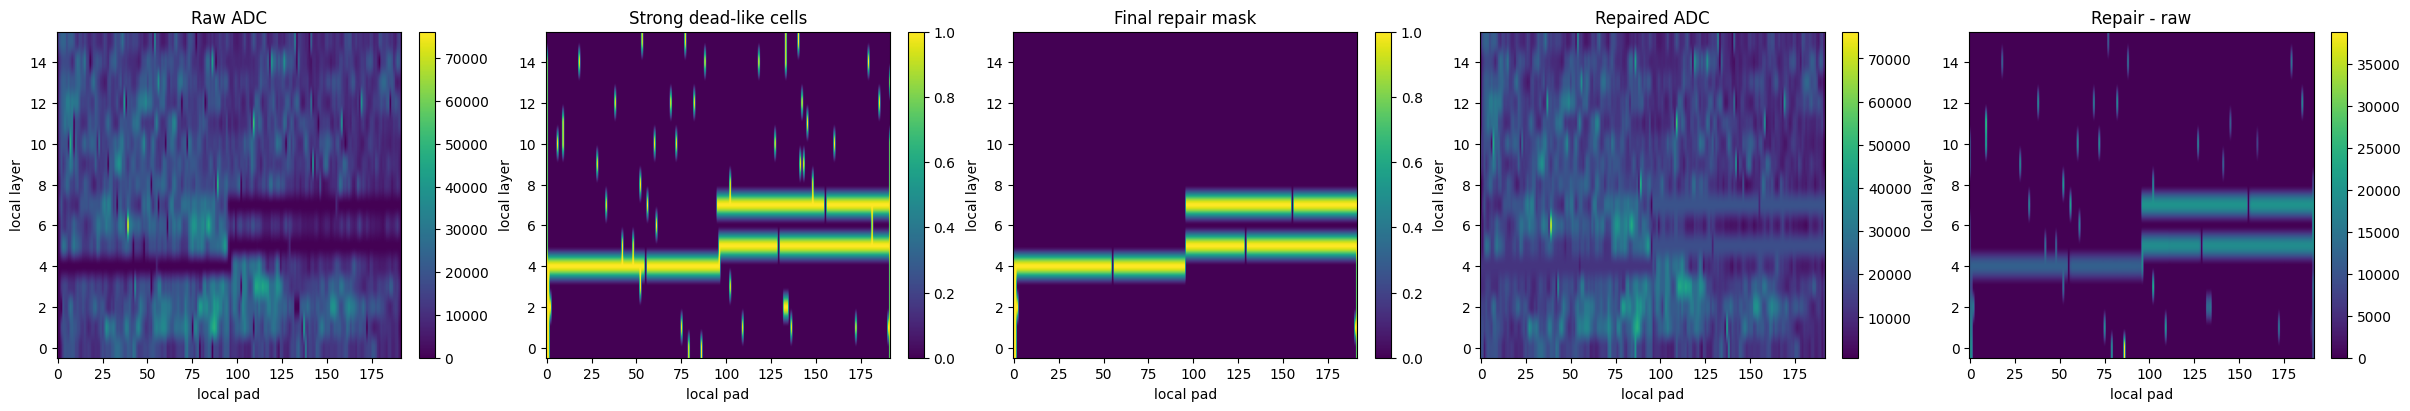

Dead FEE: []
Stripes: [('half-left', 4, 0.9895833333333334), ('half-right', 5, 0.9895833333333334), ('half-right', 7, 0.9895833333333334)]
Blocks: [(0, 4, 0, 3, 9), (0, 5, 190, 192, 6)]


In [7]:
QA_SIDE=0
QA_MODULE=2
QA_SECTOR=0

key=(QA_SIDE,QA_MODULE,QA_SECTOR)
if key in raw_maps:
    raw=raw_maps[key]["adc"]
    rep=clean_maps[key]
    m=auto_masks[key]
    mask=repair_masks[key]

    fig,ax=plt.subplots(1,5,figsize=(24,4),constrained_layout=True)
    panels=[
        (raw,"Raw ADC"),
        (m["candidate"],"Strong dead-like cells"),
        (mask,"Final repair mask"),
        (rep,"Repaired ADC"),
        (rep-raw,"Repair - raw"),
    ]
    for a,(z,title) in zip(ax,panels):
        im=a.imshow(z,aspect="auto",origin="lower")
        a.set_title(title)
        a.set_xlabel("local pad")
        a.set_ylabel("local layer")
        plt.colorbar(im,ax=a)
    plt.show()

    print("Dead FEE:",m["fee_regions"])
    print("Stripes:",m["stripe_details"])
    print("Blocks:",m["block_details"])


## 5. Build measured global `(r,phi)` ADC and IBF-density maps

For each pad,

\[
A_{\rm pad}(r)\simeq r\,\Delta\phi\,\Delta r,
\qquad
\rho_{\rm IBF}\propto ADC/A_{\rm pad}.
\]

Bins with no physical pad coverage remain `NaN`, preserving sector gaps.


In [8]:
phi_edges=np.linspace(PHI_MIN,PHI_MAX,GLOBAL_PHI_BINS+1)
phi_centers=0.5*(phi_edges[:-1]+phi_edges[1:])
all_r=np.concatenate([module_layer_radii_cm(m) for m in range(N_MODULES)])
all_r=np.sort(all_r)

def phi_bin_index(phi):
    idx=np.floor((phi-PHI_MIN)/(PHI_MAX-PHI_MIN)*GLOBAL_PHI_BINS).astype(int)
    return np.clip(idx,0,GLOBAL_PHI_BINS-1)

def build_global_measured_maps(side):
    adc_sum=np.zeros((len(all_r),GLOBAL_PHI_BINS))
    rho_sum=np.zeros_like(adc_sum)
    counts=np.zeros_like(adc_sum)
    repaired_counts=np.zeros_like(adc_sum)

    rlookup={}
    for module in range(N_MODULES):
        for il,r in enumerate(module_layer_radii_cm(module)):
            rlookup[(module,il)]=int(np.argmin(np.abs(all_r-r)))

    for module in range(N_MODULES):
        for sector in range(N_SECTORS):
            key=(side,module,sector)
            if key not in clean_maps:
                continue

            a=clean_maps[key]
            repaired=repair_masks[key]

            for il in range(LAYERS_PER_MODULE):
                ir=rlookup[(module,il)]
                phis=sector_phi_centers(module,sector,il,side)
                bins=phi_bin_index(phis)
                area=pad_area_cm2(module,il,side)

                for ip in range(a.shape[1]):
                    val=a[il,ip]
                    if not np.isfinite(val):
                        continue
                    ib=bins[ip]
                    adc_sum[ir,ib]+=val
                    rho_sum[ir,ib]+=val/area
                    counts[ir,ib]+=1
                    repaired_counts[ir,ib]+=float(repaired[il,ip])

    adc=np.full_like(adc_sum,np.nan)
    rho=np.full_like(rho_sum,np.nan)
    repaired_fraction=np.full_like(rho_sum,np.nan)

    good=counts>0
    adc[good]=adc_sum[good]/counts[good]
    rho[good]=rho_sum[good]/counts[good]
    repaired_fraction[good]=repaired_counts[good]/counts[good]

    return adc,rho,counts,repaired_fraction

adc_measured={}
ibf_measured={}
coverage_measured={}
repair_fraction_measured={}

for side in range(N_SIDES):
    (adc_measured[side],
     ibf_measured[side],
     coverage_measured[side],
     repair_fraction_measured[side]) = build_global_measured_maps(side)

print("Measured r-phi maps built")

# Explicit coverage diagnostic around +/-pi.
for side in range(N_SIDES):
    ncover=np.sum(coverage_measured[side]>0,axis=0)
    print(f"side {side}: covered phi bins = {np.count_nonzero(ncover)}/{GLOBAL_PHI_BINS}, "
          f"edge coverage (-pi,+pi) = {ncover[0]}, {ncover[-1]}")


Measured r-phi maps built
side 0: covered phi bins = 708/720, edge coverage (-pi,+pi) = 48, 48
side 1: covered phi bins = 708/720, edge coverage (-pi,+pi) = 48, 48


## 6. Safe extrapolation from R1 to the inner field cage

The radial dependence remains

\[
\rho(r,\phi)=\frac{A(\phi)}{r^\alpha},
\]

with one robust side-wide `alpha`, constrained to `0.8 <= alpha <= 2.7`.

For `A(phi)` we now save three versions:

1. **binwise** — the current method: an independent robust `A(phi)` in each measured
   phi bin.
2. **lowharmonic** — a robust Fourier smoothing using modes
   `n = 0..LOW_PHI_HARMONIC`, intended to capture broad phi modulation.
3. **sector12** — the same broad modulation plus explicit `n=12` sine/cosine terms,
   intended to capture the 12-sector structure separately.

All three are written to QA. `IBF_EXTRAPOLATION_FINAL` selects the map used downstream.


side 0: alpha=1.104; final phi model=sector12


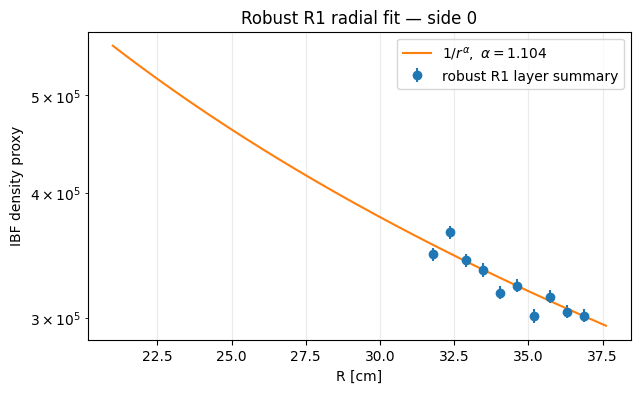

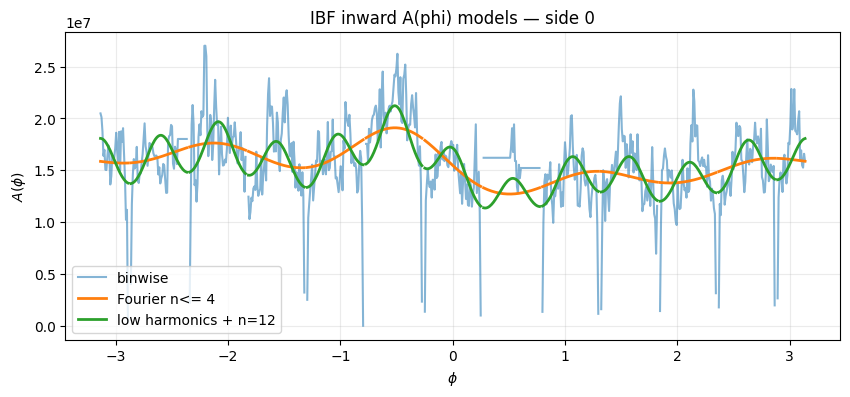

side 1: alpha=2.059; final phi model=sector12


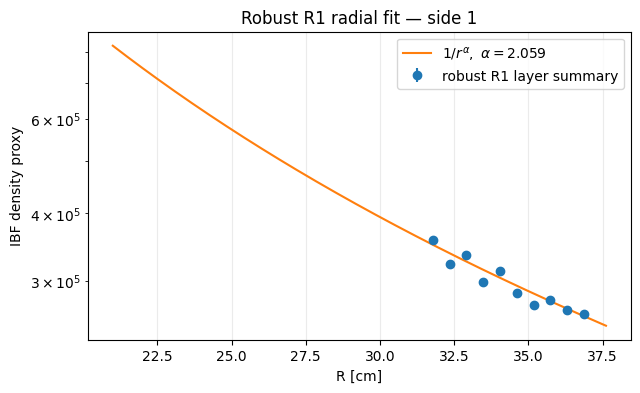

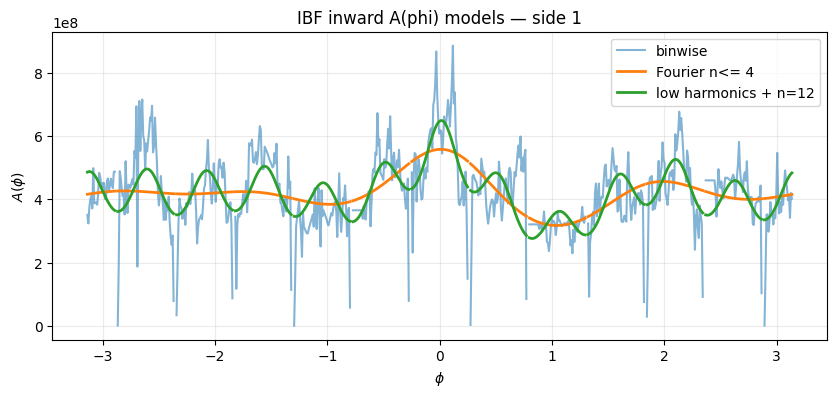

In [9]:
def robust_r1_alpha_fit(rho, coverage, repair_fraction, rvals):
    nfit=min(N_R1_FIT_LAYERS,16,len(rvals))
    fit_r=[]; fit_y=[]; fit_sigma=[]; fit_weight=[]

    for ir in range(nfit):
        y=rho[ir]
        cov=coverage[ir]>0
        rep=repair_fraction[ir]
        good=cov & np.isfinite(y) & (y>0)

        if np.count_nonzero(good)<MIN_PHI_BINS_PER_R_LAYER:
            continue

        vals=y[good]
        logv=np.log(vals)
        med=np.median(vals)
        madlog=1.4826*np.median(np.abs(logv-np.median(logv)))
        if not np.isfinite(madlog) or madlog<0.02:
            madlog=0.02

        healthy_fraction=np.mean(1.0-np.nan_to_num(rep[good],nan=1.0))
        if healthy_fraction<MIN_HEALTHY_FRACTION_FOR_ALPHA:
            continue

        n=np.count_nonzero(good)
        fit_r.append(rvals[ir])
        fit_y.append(med)
        fit_sigma.append(max(madlog/np.sqrt(max(n,1)),0.015))
        fit_weight.append(np.sqrt(healthy_fraction))

    fit_r=np.asarray(fit_r,float)
    fit_y=np.asarray(fit_y,float)
    fit_sigma=np.asarray(fit_sigma,float)
    fit_weight=np.asarray(fit_weight,float)

    if len(fit_r)<3:
        alpha=ALPHA_INITIAL
        logA=np.nanmedian(np.log(fit_y)+alpha*np.log(fit_r)) if len(fit_r) else 0.0
        return alpha,np.exp(logA),(fit_r,fit_y,fit_sigma,fit_weight),None

    logy=np.log(fit_y)

    def residual(par):
        logA,alpha=par
        return fit_weight*(logA-alpha*np.log(fit_r)-logy)/fit_sigma

    x0=[np.median(logy+ALPHA_INITIAL*np.log(fit_r)),ALPHA_INITIAL]

    result=least_squares(
        residual,x0,
        bounds=([-np.inf,ALPHA_BOUNDS[0]],[np.inf,ALPHA_BOUNDS[1]]),
        loss=ALPHA_LOSS,f_scale=ALPHA_F_SCALE
    )
    logA,alpha=result.x
    return float(alpha),float(np.exp(logA)),(fit_r,fit_y,fit_sigma,fit_weight),result


def extract_binwise_Aphi(rho, coverage, repair_fraction, rvals, alpha):
    n_amp=min(N_R1_AMPLITUDE_LAYERS,16,len(rvals))
    physical_phi=np.sum(coverage[:16]>0,axis=0)>=MIN_R1_COVERAGE_LAYERS

    Aphi=np.full(rho.shape[1],np.nan)
    quality=np.zeros(rho.shape[1])

    for iphi in range(rho.shape[1]):
        if not physical_phi[iphi]:
            continue

        vals=[]; weights=[]
        for ir in range(n_amp):
            y=rho[ir,iphi]
            if not np.isfinite(y) or y<=0 or coverage[ir,iphi]<=0:
                continue
            rep=repair_fraction[ir,iphi]
            healthy=max(0.05,1.0-(rep if np.isfinite(rep) else 1.0))
            vals.append(y*(rvals[ir]**alpha))
            weights.append(healthy)

        if len(vals)>=MIN_POINTS_FOR_PHI_AMPLITUDE:
            Aphi[iphi]=weighted_median(vals,weights)
            quality[iphi]=np.sum(weights)

    return Aphi,quality,physical_phi


def robust_fourier_fit_Aphi(Aphi,quality,max_harmonic,add_sector12=False):
    good=np.isfinite(Aphi) & (Aphi>0) & np.isfinite(quality) & (quality>0)
    phi=phi_centers[good]
    y=np.log(Aphi[good])
    q=quality[good]

    cols=[np.ones_like(phi)]
    names=["const"]
    for n in range(1,max_harmonic+1):
        cols += [np.cos(n*phi),np.sin(n*phi)]
        names += [f"cos{n}",f"sin{n}"]

    if add_sector12 and 12>max_harmonic:
        cols += [np.cos(12*phi),np.sin(12*phi)]
        names += ["cos12","sin12"]

    X=np.column_stack(cols)
    w=np.sqrt(q/np.nanmedian(q))
    coef0,*_=np.linalg.lstsq(X*w[:,None],y*w,rcond=None)

    scale=robust_scale(y)
    if not np.isfinite(scale) or scale<=0:
        scale=0.2

    def res(c):
        return w*(X@c-y)/scale

    fit=least_squares(res,coef0,loss="soft_l1",f_scale=1.0)
    coef=fit.x

    pall=phi_centers
    cols_all=[np.ones_like(pall)]
    for n in range(1,max_harmonic+1):
        cols_all += [np.cos(n*pall),np.sin(n*pall)]
    if add_sector12 and 12>max_harmonic:
        cols_all += [np.cos(12*pall),np.sin(12*pall)]

    pred=np.exp(np.column_stack(cols_all)@coef)
    pred[~np.isfinite(Aphi)] = np.nan
    return pred,coef,names,fit


def build_powerlaw_map(rho,rvals,alpha,Aphi):
    first_r=rvals[0]
    extra_r=np.linspace(IFC_RADIUS_CM,first_r,N_INNER_EXTRAP_BINS,endpoint=False)
    out_r=np.concatenate([extra_r,rvals])
    out=np.full((len(out_r),rho.shape[1]),np.nan)
    out[len(extra_r):]=rho
    for i,r in enumerate(extra_r):
        good=np.isfinite(Aphi)
        out[i,good]=Aphi[good]/(r**alpha)
    return out_r,out,len(extra_r)


ibf_map_variants={}
ibf_map={}
ibf_alpha={}
ibf_Aphi_variants={}
ibf_alpha_fit_points={}
ibf_phi_fit_coeff={}

for side in range(N_SIDES):
    alpha,A0,fitpts,result=robust_r1_alpha_fit(
        ibf_measured[side],coverage_measured[side],
        repair_fraction_measured[side],all_r
    )
    ibf_alpha[side]=alpha
    ibf_alpha_fit_points[side]=fitpts

    A_bin,q_bin,_=extract_binwise_Aphi(
        ibf_measured[side],coverage_measured[side],
        repair_fraction_measured[side],all_r,alpha
    )
    A_low,c_low,n_low,_=robust_fourier_fit_Aphi(
        A_bin,q_bin,LOW_PHI_HARMONIC,False
    )
    A_sec,c_sec,n_sec,_=robust_fourier_fit_Aphi(
        A_bin,q_bin,LOW_PHI_HARMONIC,True
    )

    ibf_Aphi_variants[side]={
        "binwise":A_bin,
        "lowharmonic":A_low,
        "sector12":A_sec
    }
    ibf_phi_fit_coeff[side]={
        "lowharmonic":(c_low,n_low),
        "sector12":(c_sec,n_sec)
    }

    ibf_map_variants[side]={}
    for mode,Aphi in ibf_Aphi_variants[side].items():
        r_full,tmp,n_extrap=build_powerlaw_map(
            ibf_measured[side],all_r,alpha,Aphi
        )
        ibf_map_variants[side][mode]=tmp

    ibf_map[side]=ibf_map_variants[side][IBF_EXTRAPOLATION_FINAL]

    print(f"side {side}: alpha={alpha:.3f}; final phi model={IBF_EXTRAPOLATION_FINAL}")

    fr,fy,fs,fw=fitpts
    if len(fr):
        plt.figure(figsize=(7,4))
        plt.errorbar(fr,fy,yerr=fy*fs,fmt="o",label="robust R1 layer summary")
        rr=np.linspace(IFC_RADIUS_CM,max(fr)*1.02,200)
        logA=np.median(np.log(fy)+alpha*np.log(fr))
        plt.plot(rr,np.exp(logA)/rr**alpha,
                 label=fr"$1/r^{{\alpha}},\ \alpha={alpha:.3f}$")
        plt.yscale("log")
        plt.xlabel("R [cm]")
        plt.ylabel("IBF density proxy")
        plt.title(f"Robust R1 radial fit — side {side}")
        plt.grid(alpha=0.25); plt.legend()
        plt.savefig(QA_PLOT_DIR/f"ibf_alpha_fit_side{side}.png",
                    dpi=160,bbox_inches="tight")
        plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(phi_centers,A_bin,label="binwise",alpha=0.55)
    plt.plot(phi_centers,A_low,label=f"Fourier n<= {LOW_PHI_HARMONIC}",lw=2)
    plt.plot(phi_centers,A_sec,label="low harmonics + n=12",lw=2)
    plt.xlabel(r"$\phi$")
    plt.ylabel(r"$A(\phi)$")
    plt.title(f"IBF inward A(phi) models — side {side}")
    plt.grid(alpha=0.25); plt.legend()
    plt.savefig(QA_PLOT_DIR/f"ibf_Aphi_models_side{side}.png",
                dpi=160,bbox_inches="tight")
    plt.show()


## 7. Final IBF maps and r / phi profiles

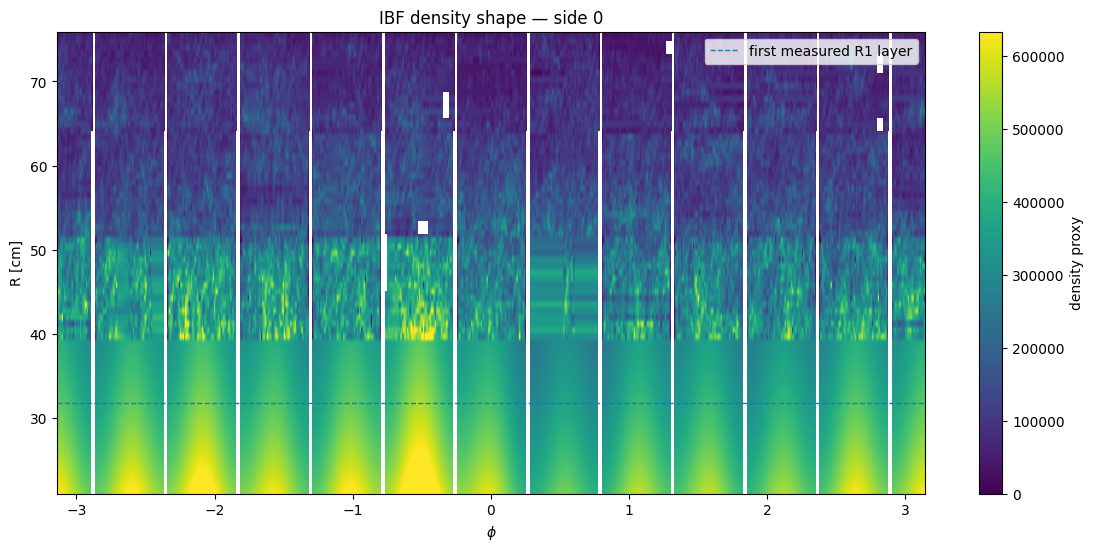

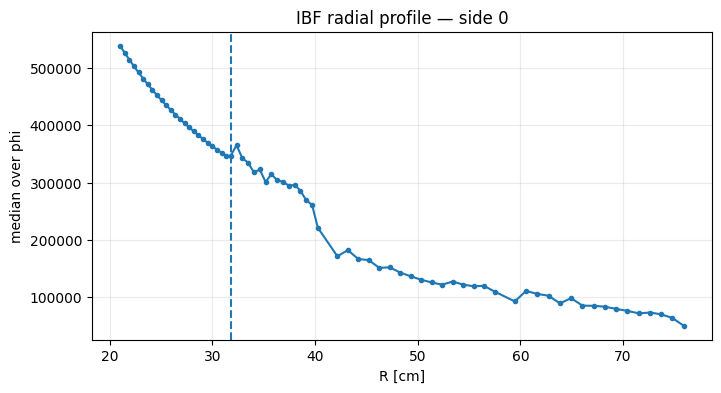

/tmp/ipykernel_9114/954127439.py:44: RuntimeWarning: All-NaN slice encountered
  ibf_profile_phi[side] = np.nanmedian(ibf_map[side],axis=0)


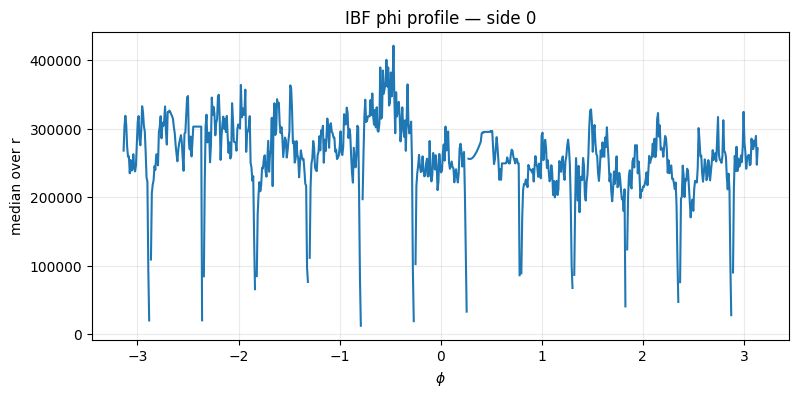

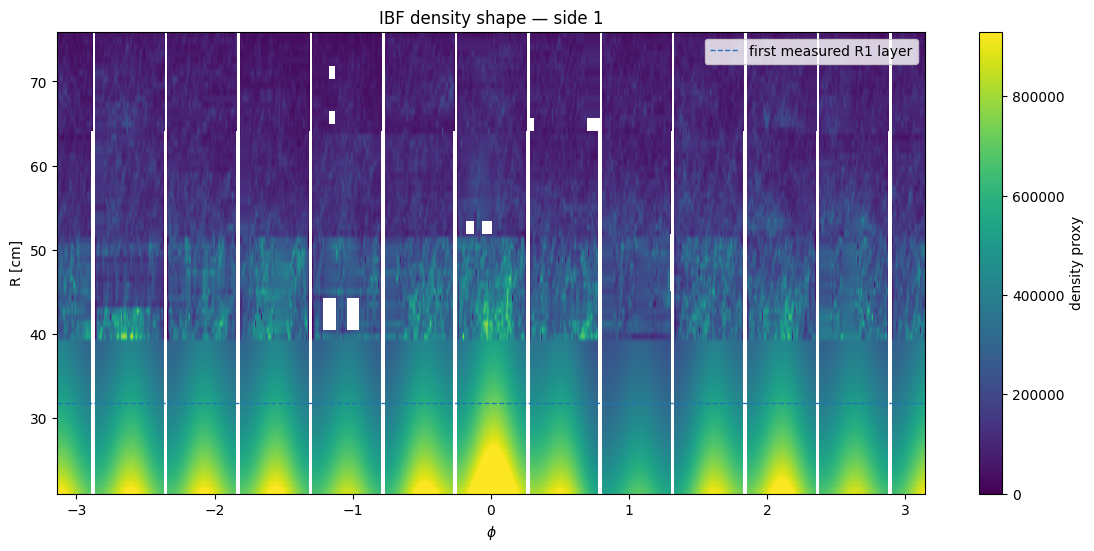

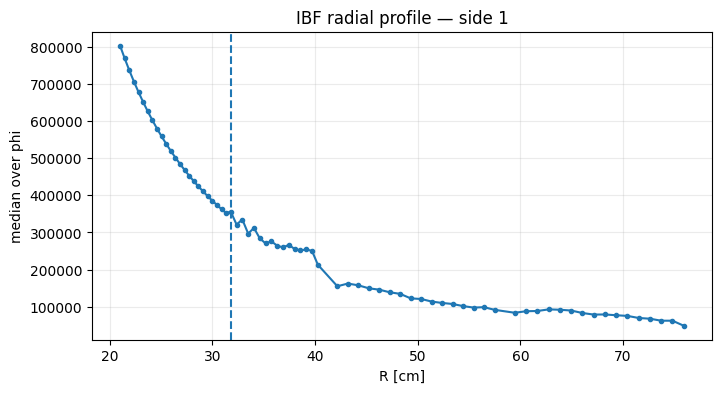

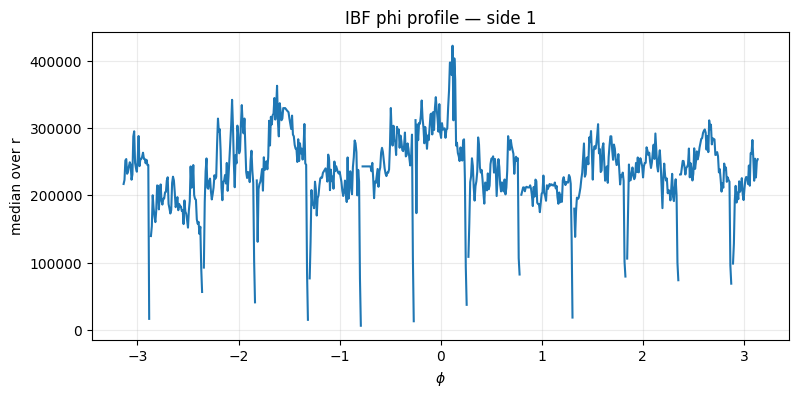

In [10]:
def save_current_figure(name):
    path = QA_PLOT_DIR / f"{name}.png"
    plt.savefig(path, dpi=160, bbox_inches="tight")
    return path

def plot_rphi(data,rvals,title,label="density proxy",save_name=None):
    finite=data[np.isfinite(data)]
    vmax=np.quantile(finite,0.995) if finite.size else None
    plt.figure(figsize=(14,6))
    plt.imshow(data,origin="lower",aspect="auto",
               extent=[PHI_MIN,PHI_MAX,rvals[0],rvals[-1]],
               vmin=0,vmax=vmax)
    plt.xlabel(r"$\phi$")
    plt.ylabel("R [cm]")
    plt.title(title)
    plt.colorbar(label=label)
    plt.axhline(all_r[0],ls="--",lw=1,label="first measured R1 layer")
    plt.legend()
    if save_name:
        save_current_figure(save_name)
    plt.show()

ibf_profile_r = {}
ibf_profile_phi = {}

for side in range(N_SIDES):
    plot_rphi(
        ibf_map[side],r_full,
        f"IBF density shape — side {side}",
        save_name=f"ibf_density_side{side}"
    )

    ibf_profile_r[side] = np.nanmedian(ibf_map[side],axis=1)
    plt.figure(figsize=(8,4))
    plt.plot(r_full,ibf_profile_r[side],marker=".")
    plt.axvline(all_r[0],ls="--")
    plt.xlabel("R [cm]")
    plt.ylabel("median over phi")
    plt.title(f"IBF radial profile — side {side}")
    plt.grid(alpha=0.25)
    save_current_figure(f"ibf_radial_profile_side{side}")
    plt.show()

    ibf_profile_phi[side] = np.nanmedian(ibf_map[side],axis=0)
    plt.figure(figsize=(9,4))
    plt.plot(phi_centers,ibf_profile_phi[side])
    plt.xlabel(r"$\phi$")
    plt.ylabel("median over r")
    plt.title(f"IBF phi profile — side {side}")
    plt.grid(alpha=0.25)
    save_current_figure(f"ibf_phi_profile_side{side}")
    plt.show()


## 8. Smooth 2D diagnostic fit in both r and phi

Periodic Fourier terms in phi are combined with low-order radial polynomials:

\[
\rho(r,\phi)=
\sum_k a_k r_n^k+
\sum_{n=1}^{N}\sum_k
\left[b_{nk}r_n^k\cos(n\phi)+c_{nk}r_n^k\sin(n\phi)\right].
\]

This is only a diagnostic representation. The repaired histogram can remain the
actual PHGarfield source.


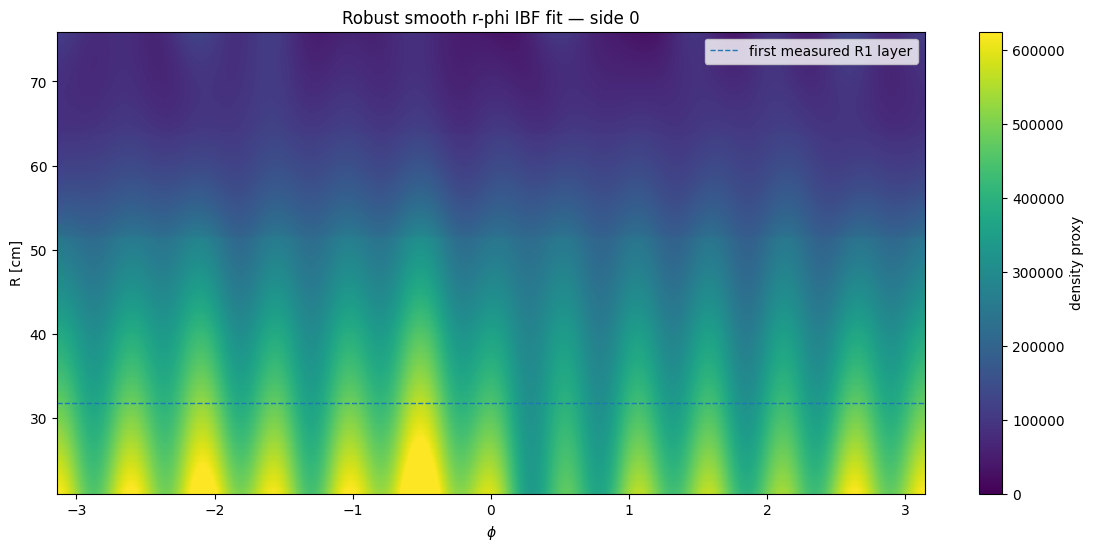

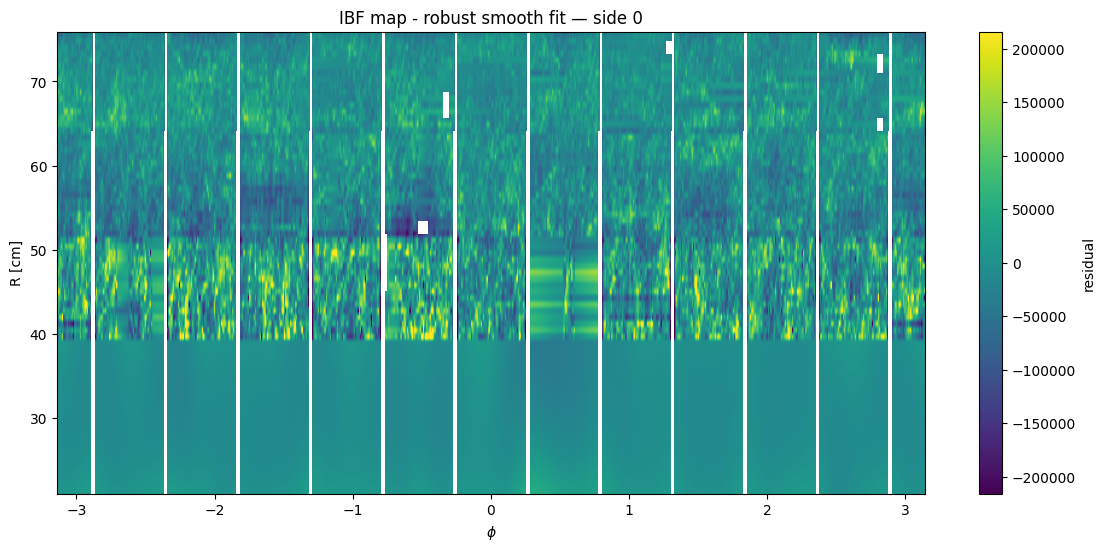

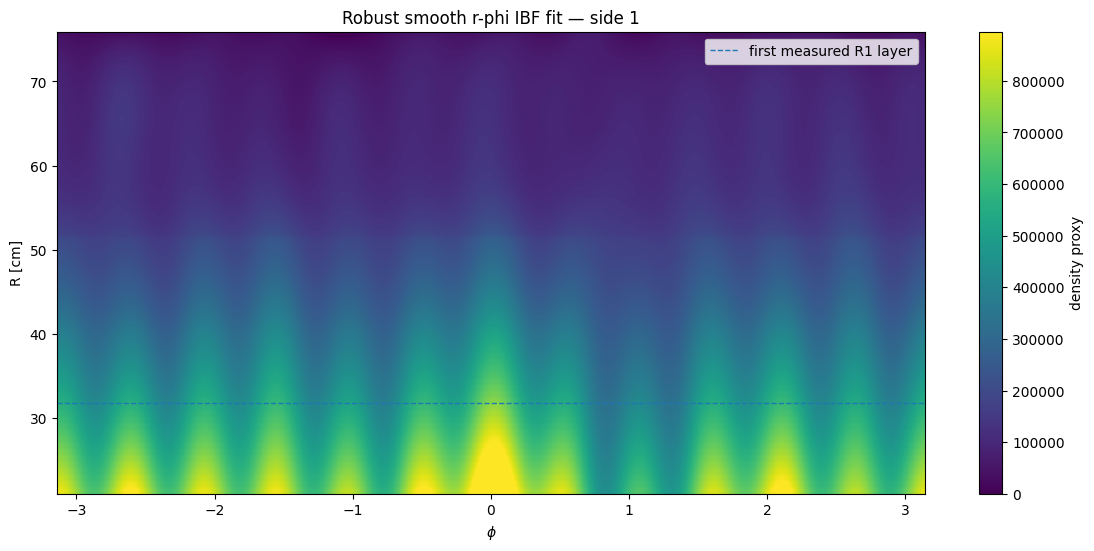

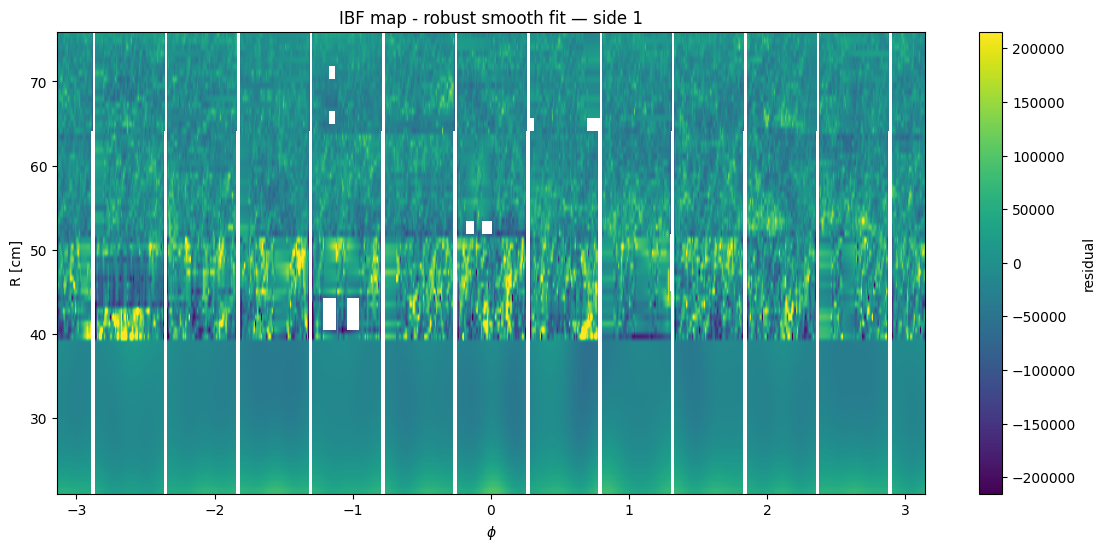

In [11]:
def design_matrix(r,phi):
    r=np.asarray(r,float)
    phi=np.asarray(phi,float)
    rmid=0.5*(r_full.min()+r_full.max())
    rscale=0.5*(r_full.max()-r_full.min())
    rn=(r-rmid)/rscale

    cols=[]
    names=[]

    for k in range(RADIAL_POLY_ORDER+1):
        cols.append(rn**k)
        names.append(f"r^{k}")

    for n in range(1,FOURIER_ORDER+1):
        for k in range(RADIAL_POLY_ORDER+1):
            cols.append((rn**k)*np.cos(n*phi))
            names.append(f"r^{k} cos({n}phi)")
        for k in range(RADIAL_POLY_ORDER+1):
            cols.append((rn**k)*np.sin(n*phi))
            names.append(f"r^{k} sin({n}phi)")

    return np.column_stack(cols),names

def fit_smooth_rphi(data,rvals,phivals):
    R,P=np.meshgrid(rvals,phivals,indexing="ij")
    y=data.ravel()
    rr=R.ravel()
    pp=P.ravel()
    good=np.isfinite(y) & (y>=FIT_MIN_DENSITY)

    X,names=design_matrix(rr[good],pp[good])
    yg=y[good]

    # Start from linear least squares.
    coef0,*_=np.linalg.lstsq(X,yg,rcond=None)

    if ROBUST_2D_FIT:
        scale=robust_scale(yg)
        if not np.isfinite(scale) or scale<=0:
            scale=max(np.nanmedian(np.abs(yg)),1.0)

        # Scale residuals so isolated hot/dead artifacts do not dominate.
        def res(c):
            return (X@c-yg)/scale

        fit=least_squares(
            res,coef0,
            loss=ROBUST_2D_LOSS,
            f_scale=1.0,
            max_nfev=40
        )
        coef=fit.x
    else:
        coef=coef0

    Xall,_=design_matrix(rr,pp)
    pred=(Xall@coef).reshape(data.shape)
    return coef,names,np.clip(pred,0,None)

ibf_fit={}
ibf_fit_coeff={}

for side in range(N_SIDES):
    coef,names,pred=fit_smooth_rphi(ibf_map[side],r_full,phi_centers)
    ibf_fit[side]=pred
    ibf_fit_coeff[side]=(coef,names)

    plot_rphi(pred,r_full,f"Robust smooth r-phi IBF fit — side {side}", save_name=f"ibf_2dfit_side{side}")

    resid=ibf_map[side]-pred
    finite=resid[np.isfinite(resid)]
    lim=np.quantile(np.abs(finite),0.995) if finite.size else None
    plt.figure(figsize=(14,6))
    plt.imshow(resid,origin="lower",aspect="auto",
               extent=[PHI_MIN,PHI_MAX,r_full[0],r_full[-1]],
               vmin=-lim if lim else None,vmax=lim)
    plt.xlabel(r"$\phi$")
    plt.ylabel("R [cm]")
    plt.title(f"IBF map - robust smooth fit — side {side}")
    plt.colorbar(label="residual")
    save_current_figure(f"ibf_2dfit_residual_side{side}")
    plt.show()


# Part II — primary-ionization density

The gain map is **sector × layer**, not `(phi,r)`. Therefore it must be applied
before merging native pads into the global `(r,phi)` map.

For each cleaned pad:
1. read gain from `(sector, TPC_layer-7)`;
2. compute `ADC/gain`;
3. divide by the exact pad area;
4. then fill global `(r,phi)`.

Primary then gets its own robust `1/r^alpha` extrapolation and the same three
`A(phi)` QA models.


PRIMARY side 0: alpha=1.830


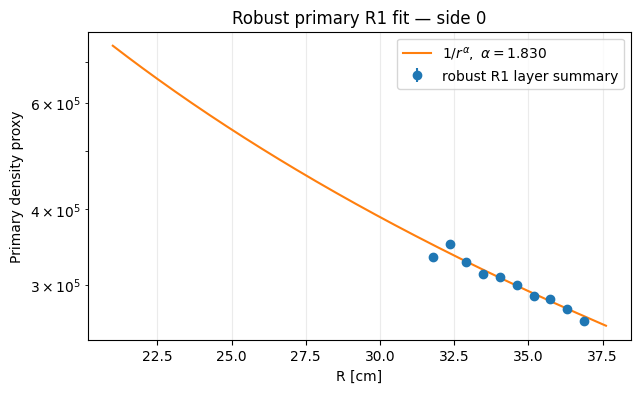

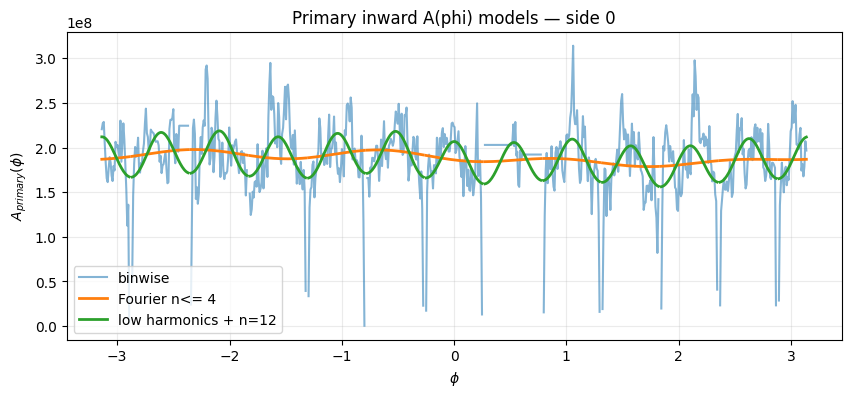

PRIMARY side 1: alpha=2.356


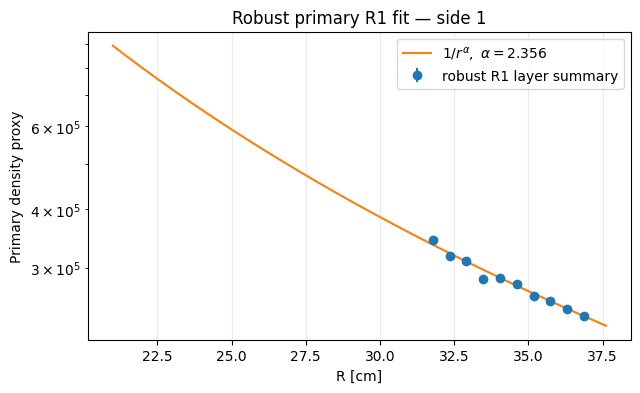

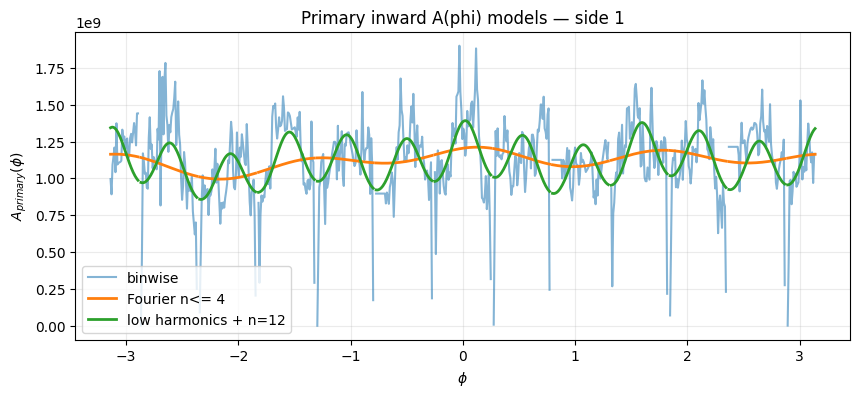

In [12]:
def get_gain_hist_name(side):
    return GAIN_MAP_HIST_SIDE0 if side==0 else GAIN_MAP_HIST_SIDE1

def load_gain_histograms():
    fg=root.TFile.Open(str(GAIN_MAP_FILE),"READ")
    if not fg or fg.IsZombie():
        raise OSError(f"Cannot open gain file: {GAIN_MAP_FILE}")

    out={}
    for side in range(N_SIDES):
        name=get_gain_hist_name(side)
        h=fg.Get(name)
        if not h:
            raise KeyError(f"Missing gain histogram: {name}")
        h=h.Clone(f"{name}_clone")
        h.SetDirectory(0)
        out[side]=h

    fg.Close()
    return out

gain_hist=load_gain_histograms()

def gain_for_sector_layer(side,sector,global_tpc_layer):
    h=gain_hist[side]
    gain_layer=global_tpc_layer-GAIN_LAYER_OFFSET
    bx=h.GetXaxis().FindBin(sector+0.5)
    by=h.GetYaxis().FindBin(gain_layer+0.5)
    g=h.GetBinContent(bx,by)
    return float(g) if np.isfinite(g) and g>0 else np.nan

def build_primary_measured_from_native(side):
    rho_sum=np.zeros((len(all_r),GLOBAL_PHI_BINS))
    counts=np.zeros_like(rho_sum)

    rlookup={}
    for module in range(N_MODULES):
        for il,r in enumerate(module_layer_radii_cm(module)):
            rlookup[(module,il)]=int(np.argmin(np.abs(all_r-r)))

    for module in range(N_MODULES):
        for sector in range(N_SECTORS):
            key=(side,module,sector)
            if key not in clean_maps:
                continue
            a=clean_maps[key]

            for il in range(LAYERS_PER_MODULE):
                glayer=global_layer(module,il)
                g=gain_for_sector_layer(side,sector,glayer)
                if not np.isfinite(g):
                    continue

                ir=rlookup[(module,il)]
                phis=sector_phi_centers(module,sector,il,side)
                bins=phi_bin_index(phis)
                area=pad_area_cm2(module,il,side)

                for ip in range(a.shape[1]):
                    val=a[il,ip]
                    if not np.isfinite(val):
                        continue

                    rho=(val/g)/area if PRIMARY_DIVIDE_BY_GAIN else val/area
                    ib=bins[ip]
                    rho_sum[ir,ib]+=rho
                    counts[ir,ib]+=1

    out=np.full_like(rho_sum,np.nan)
    good=counts>0
    out[good]=rho_sum[good]/counts[good]
    return out,counts

primary_measured={}
primary_coverage={}
for side in range(N_SIDES):
    primary_measured[side],primary_coverage[side]=build_primary_measured_from_native(side)

primary_map={}
primary_map_variants={}
primary_Aphi_variants={}
primary_alpha={}
primary_alpha_fit_points={}

for side in range(N_SIDES):
    alpha,A0,fitpts,result=robust_r1_alpha_fit(
        primary_measured[side],primary_coverage[side],
        repair_fraction_measured[side],all_r
    )
    primary_alpha[side]=alpha
    primary_alpha_fit_points[side]=fitpts

    A_bin,q_bin,_=extract_binwise_Aphi(
        primary_measured[side],primary_coverage[side],
        repair_fraction_measured[side],all_r,alpha
    )
    A_low,_,_,_=robust_fourier_fit_Aphi(
        A_bin,q_bin,LOW_PHI_HARMONIC,False
    )
    A_sec,_,_,_=robust_fourier_fit_Aphi(
        A_bin,q_bin,LOW_PHI_HARMONIC,True
    )

    primary_Aphi_variants[side]={
        "binwise":A_bin,
        "lowharmonic":A_low,
        "sector12":A_sec
    }
    primary_map_variants[side]={}

    for mode,Aphi in primary_Aphi_variants[side].items():
        r_primary,tmp,_=build_powerlaw_map(
            primary_measured[side],all_r,alpha,Aphi
        )
        primary_map_variants[side][mode]=tmp

    primary_map[side]=primary_map_variants[side][IBF_EXTRAPOLATION_FINAL]

    print(f"PRIMARY side {side}: alpha={alpha:.3f}")

    fr,fy,fs,fw=fitpts
    if len(fr):
        plt.figure(figsize=(7,4))
        plt.errorbar(fr,fy,yerr=fy*fs,fmt="o",label="robust R1 layer summary")
        rr=np.linspace(IFC_RADIUS_CM,max(fr)*1.02,200)
        logA=np.median(np.log(fy)+alpha*np.log(fr))
        plt.plot(rr,np.exp(logA)/rr**alpha,
                 label=fr"$1/r^{{\alpha}},\ \alpha={alpha:.3f}$")
        plt.yscale("log")
        plt.xlabel("R [cm]")
        plt.ylabel("Primary density proxy")
        plt.title(f"Robust primary R1 fit — side {side}")
        plt.grid(alpha=0.25); plt.legend()
        plt.savefig(QA_PLOT_DIR/f"primary_alpha_fit_side{side}.png",
                    dpi=160,bbox_inches="tight")
        plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(phi_centers,A_bin,label="binwise",alpha=0.55)
    plt.plot(phi_centers,A_low,label=f"Fourier n<= {LOW_PHI_HARMONIC}",lw=2)
    plt.plot(phi_centers,A_sec,label="low harmonics + n=12",lw=2)
    plt.xlabel(r"$\phi$")
    plt.ylabel(r"$A_{primary}(\phi)$")
    plt.title(f"Primary inward A(phi) models — side {side}")
    plt.grid(alpha=0.25); plt.legend()
    plt.savefig(QA_PLOT_DIR/f"primary_Aphi_models_side{side}.png",
                dpi=160,bbox_inches="tight")
    plt.show()

assert np.allclose(r_primary,r_full)


## Primary maps, profiles, and 2D fits

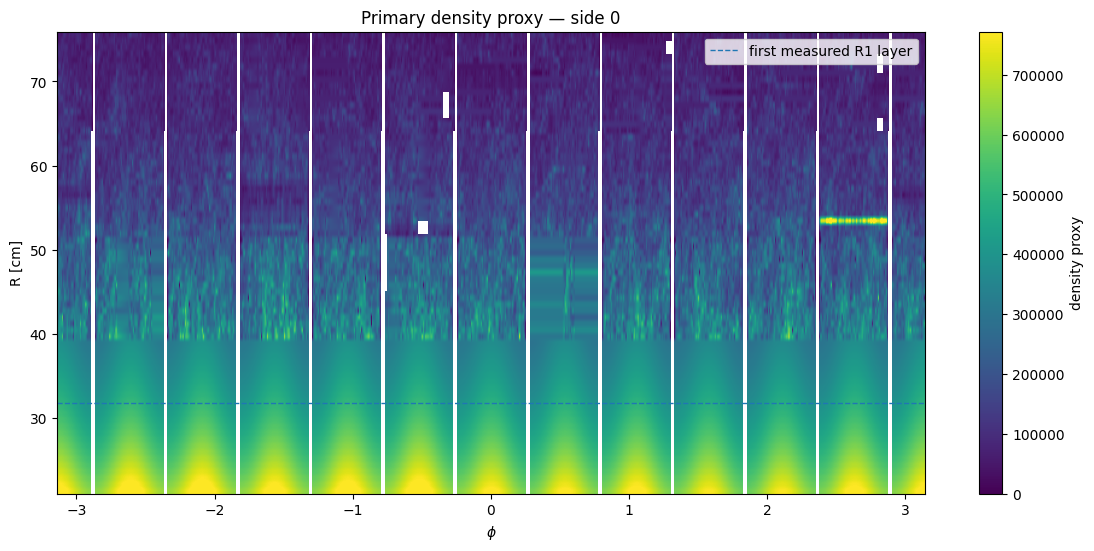

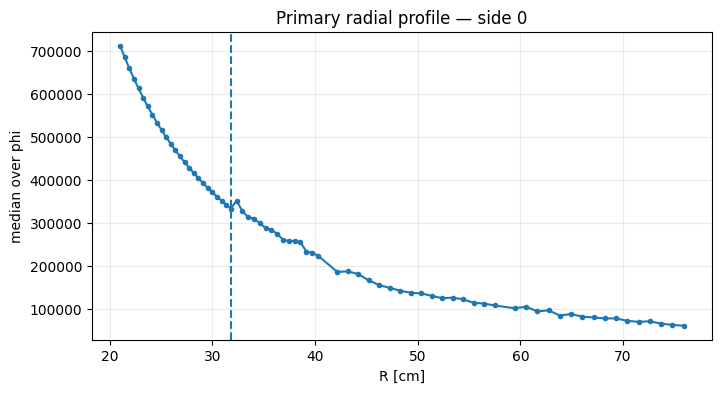

/tmp/ipykernel_9114/555725130.py:24: RuntimeWarning: All-NaN slice encountered
  primary_profile_phi[side]=np.nanmedian(primary_map[side],axis=0)


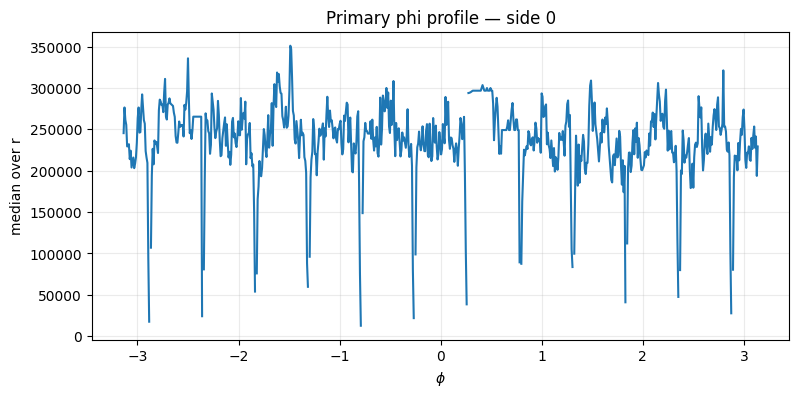

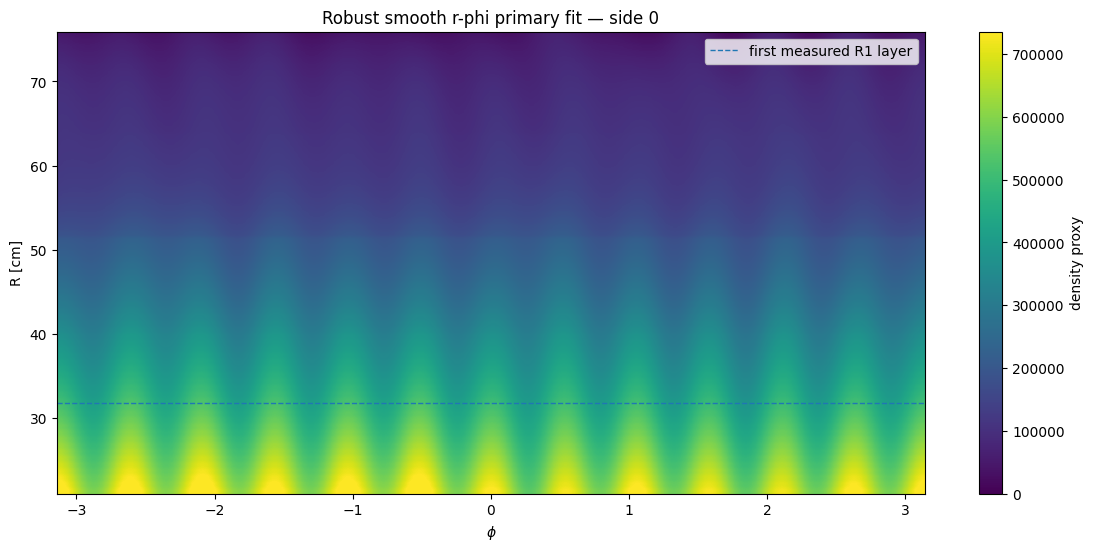

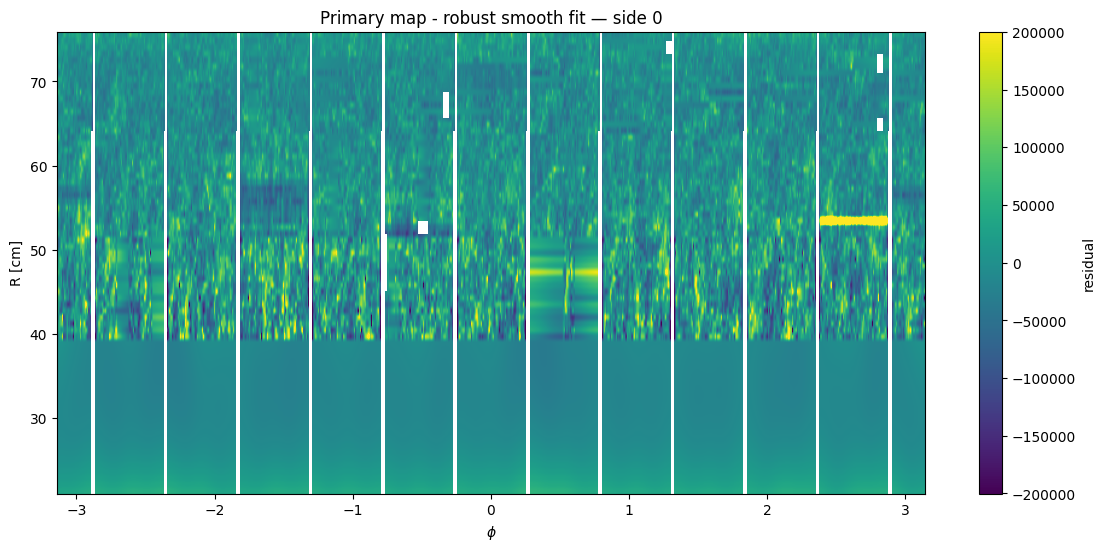

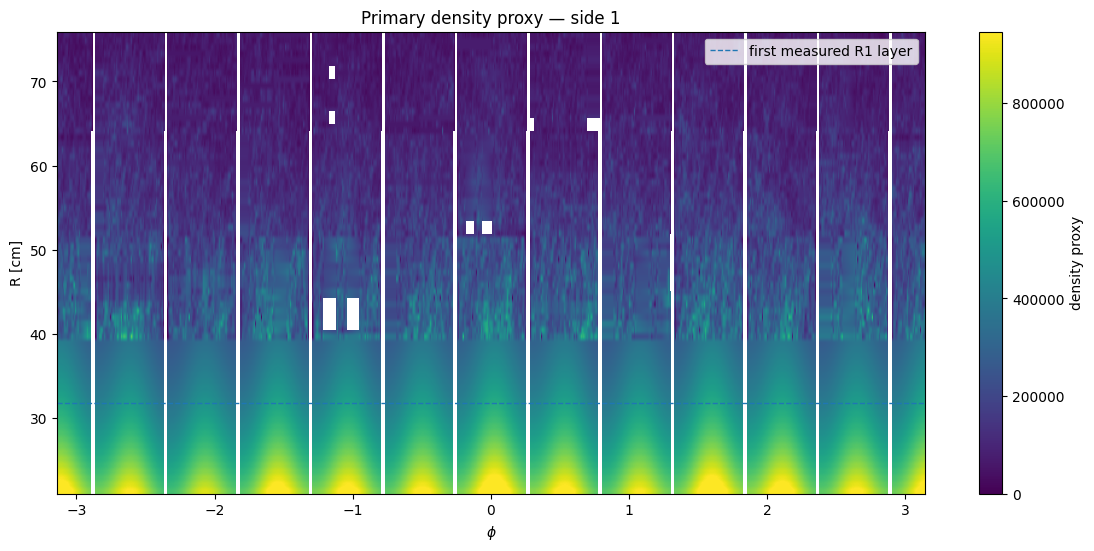

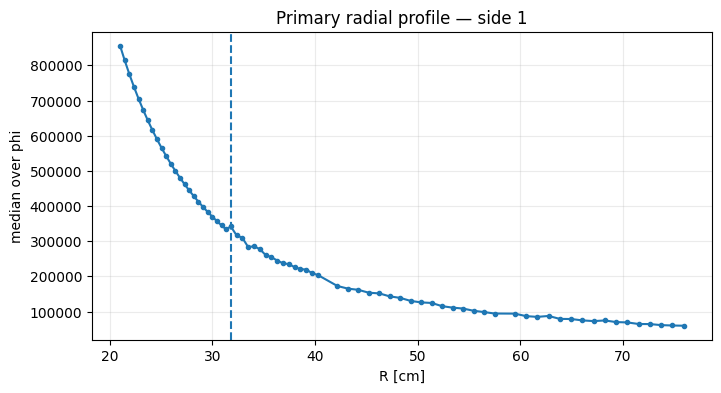

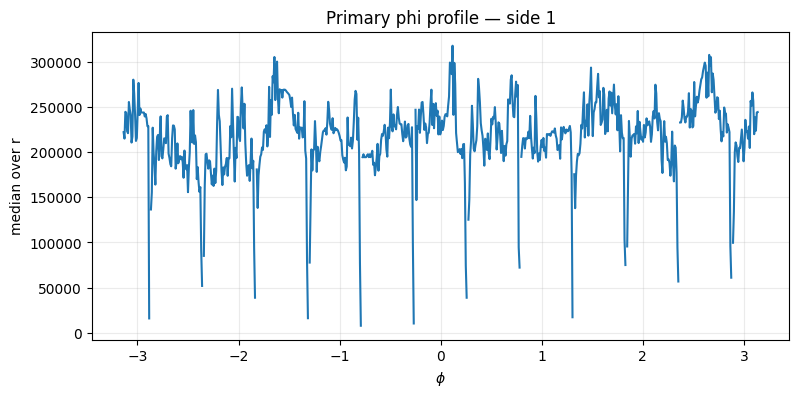

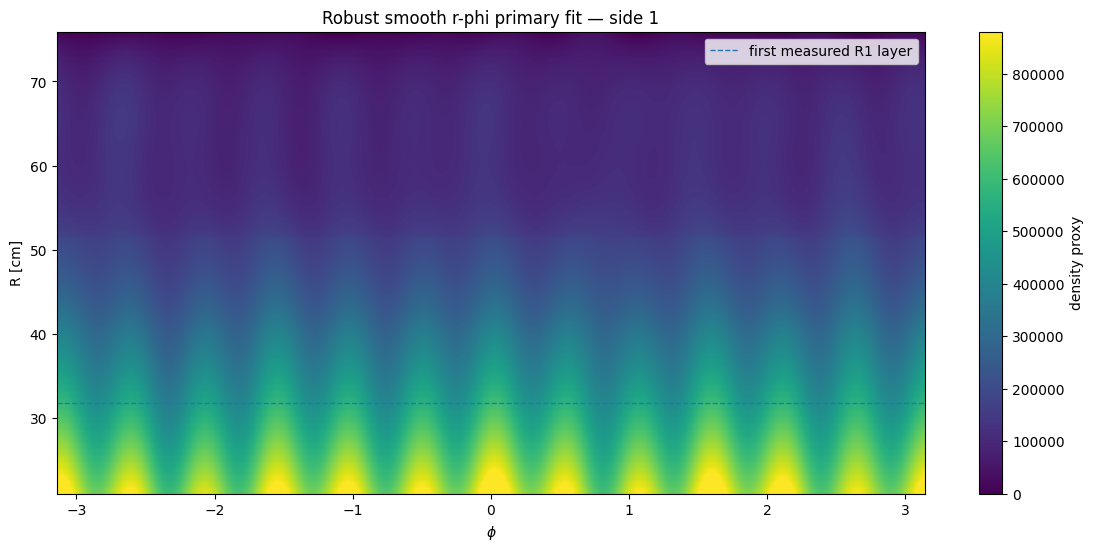

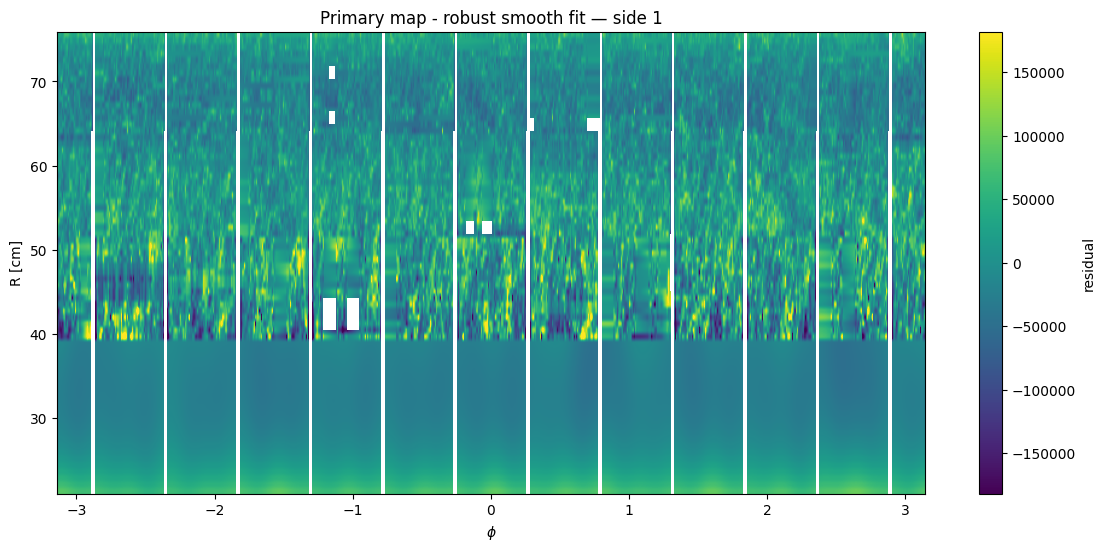

In [13]:
primary_fit={}
primary_fit_coeff={}
primary_profile_r={}
primary_profile_phi={}

for side in range(N_SIDES):
    plot_rphi(
        primary_map[side],r_full,
        f"Primary density proxy — side {side}",
        save_name=f"primary_density_side{side}"
    )

    primary_profile_r[side]=np.nanmedian(primary_map[side],axis=1)
    plt.figure(figsize=(8,4))
    plt.plot(r_full,primary_profile_r[side],marker=".")
    plt.axvline(all_r[0],ls="--")
    plt.xlabel("R [cm]")
    plt.ylabel("median over phi")
    plt.title(f"Primary radial profile — side {side}")
    plt.grid(alpha=0.25)
    save_current_figure(f"primary_radial_profile_side{side}")
    plt.show()

    primary_profile_phi[side]=np.nanmedian(primary_map[side],axis=0)
    plt.figure(figsize=(9,4))
    plt.plot(phi_centers,primary_profile_phi[side])
    plt.xlabel(r"$\phi$")
    plt.ylabel("median over r")
    plt.title(f"Primary phi profile — side {side}")
    plt.grid(alpha=0.25)
    save_current_figure(f"primary_phi_profile_side{side}")
    plt.show()

    coef,names,pred=fit_smooth_rphi(primary_map[side],r_full,phi_centers)
    primary_fit[side]=pred
    primary_fit_coeff[side]=(coef,names)
    plot_rphi(
        pred,r_full,
        f"Robust smooth r-phi primary fit — side {side}",
        save_name=f"primary_2dfit_side{side}"
    )

    resid=primary_map[side]-pred
    finite=resid[np.isfinite(resid)]
    lim=np.quantile(np.abs(finite),0.995) if finite.size else None
    plt.figure(figsize=(14,6))
    plt.imshow(resid,origin="lower",aspect="auto",
               extent=[PHI_MIN,PHI_MAX,r_full[0],r_full[-1]],
               vmin=-lim if lim else None,vmax=lim)
    plt.xlabel(r"$\phi$")
    plt.ylabel("R [cm]")
    plt.title(f"Primary map - robust smooth fit — side {side}")
    plt.colorbar(label="residual")
    save_current_figure(f"primary_2dfit_residual_side{side}")
    plt.show()


## Save the final maps to ROOT

In [14]:
def centers_to_edges(x):
    x=np.asarray(x,float)
    e=np.empty(len(x)+1)
    e[1:-1]=0.5*(x[:-1]+x[1:])
    e[0]=x[0]-0.5*(x[1]-x[0])
    e[-1]=x[-1]+0.5*(x[-1]-x[-2])
    return e

def numpy_to_th2(name,title,data,rvals):
    pedges=np.linspace(PHI_MIN,PHI_MAX,GLOBAL_PHI_BINS+1)
    redges=centers_to_edges(rvals)
    h=root.TH2D(name,title,
                GLOBAL_PHI_BINS,array("d",pedges),
                len(rvals),array("d",redges))
    h.SetDirectory(0)
    for ir in range(len(rvals)):
        for ip in range(GLOBAL_PHI_BINS):
            v=data[ir,ip]
            h.SetBinContent(ip+1,ir+1,float(v) if np.isfinite(v) else 0.0)
    return h

def numpy_to_th1_centers(name,title,values,centers,xlabel,ylabel):
    edges=centers_to_edges(centers)
    h=root.TH1D(name,f"{title};{xlabel};{ylabel}",len(centers),array("d",edges))
    h.SetDirectory(0)
    for i,v in enumerate(values):
        h.SetBinContent(i+1,float(v) if np.isfinite(v) else 0.0)
    return h

def phi_profile_to_th1(name,title,values):
    edges=np.linspace(PHI_MIN,PHI_MAX,len(values)+1)
    h=root.TH1D(name,f"{title};#phi;median density",len(values),array("d",edges))
    h.SetDirectory(0)
    for i,v in enumerate(values):
        h.SetBinContent(i+1,float(v) if np.isfinite(v) else 0.0)
    return h

def fit_points_to_graph(name,fitpts):
    fr,fy,fs,fw=fitpts
    g=root.TGraphErrors(len(fr))
    g.SetName(name)
    g.SetTitle(name)
    for i,(r,y,s) in enumerate(zip(fr,fy,fs)):
        g.SetPoint(i,float(r),float(y))
        g.SetPointError(i,0.0,float(y*s))
    return g

# ------------------------------------------------------------
# Main physics maps ROOT file
# ------------------------------------------------------------
fout=root.TFile.Open(str(OUTPUT_ROOT),"RECREATE")

for side in range(N_SIDES):
    objects=[
        numpy_to_th2(
            f"h_ibf_density_binwise_rphi_side{side}",
            f"IBF binwise inward model side {side};#phi;R [cm];arb. density",
            ibf_map_variants[side]["binwise"],r_full),
        numpy_to_th2(
            f"h_ibf_density_lowharmonic_rphi_side{side}",
            f"IBF low-harmonic inward model side {side};#phi;R [cm];arb. density",
            ibf_map_variants[side]["lowharmonic"],r_full),
        numpy_to_th2(
            f"h_ibf_density_sector12_rphi_side{side}",
            f"IBF low+12 inward model side {side};#phi;R [cm];arb. density",
            ibf_map_variants[side]["sector12"],r_full),
        numpy_to_th2(
            f"h_ibf_density_shape_rphi_side{side}",
            f"IBF density shape side {side};#phi;R [cm];arb. density",
            ibf_map[side],r_full),
        numpy_to_th2(
            f"h_ibf_density_fit_rphi_side{side}",
            f"Robust smooth IBF fit side {side};#phi;R [cm];arb. density",
            ibf_fit[side],r_full),
        numpy_to_th2(
            f"h_primary_density_rphi_side{side}",
            f"Primary density side {side};#phi;R [cm];arb. density",
            primary_map[side],r_full),
        numpy_to_th2(
            f"h_primary_density_fit_rphi_side{side}",
            f"Robust smooth primary fit side {side};#phi;R [cm];arb. density",
            primary_fit[side],r_full),
    ]
    for h in objects:
        h.Write()

fout.Close()

# ------------------------------------------------------------
# QA ROOT file
# ------------------------------------------------------------
fqa=root.TFile.Open(str(QA_ROOT),"RECREATE")

for side in range(N_SIDES):
    # measured maps
    numpy_to_th2(
        f"h_ibf_measured_side{side}",
        f"Measured IBF proxy side {side};#phi;R [cm];arb.",
        ibf_measured[side],all_r).Write()

    numpy_to_th2(
        f"h_primary_measured_side{side}",
        f"Measured primary proxy side {side};#phi;R [cm];arb.",
        primary_measured[side],all_r).Write()

    numpy_to_th2(
        f"h_repair_fraction_side{side}",
        f"Repair fraction side {side};#phi;R [cm];fraction",
        repair_fraction_measured[side],all_r).Write()

    hg=gain_hist[side].Clone(f"h_gain_sector_layer_side{side}")
    hg.SetDirectory(0)
    hg.Write()

    # inward-extrapolation variants and A(phi) QA
    for mode in ("binwise","lowharmonic","sector12"):
        numpy_to_th2(
            f"h_ibf_extrap_{mode}_side{side}",
            f"IBF extrapolation {mode} side {side};#phi;R [cm];arb.",
            ibf_map_variants[side][mode],r_full).Write()

        numpy_to_th2(
            f"h_primary_extrap_{mode}_side{side}",
            f"Primary extrapolation {mode} side {side};#phi;R [cm];arb.",
            primary_map_variants[side][mode],r_full).Write()

        phi_profile_to_th1(
            f"h_ibf_Aphi_{mode}_side{side}",
            f"IBF A(phi) {mode} side {side}",
            ibf_Aphi_variants[side][mode]).Write()

        phi_profile_to_th1(
            f"h_primary_Aphi_{mode}_side{side}",
            f"Primary A(phi) {mode} side {side}",
            primary_Aphi_variants[side][mode]).Write()

    # final maps / fits / residuals
    numpy_to_th2(
        f"h_ibf_final_side{side}",
        f"Final IBF side {side};#phi;R [cm];arb.",
        ibf_map[side],r_full).Write()

    numpy_to_th2(
        f"h_ibf_fit_side{side}",
        f"IBF 2D fit side {side};#phi;R [cm];arb.",
        ibf_fit[side],r_full).Write()

    numpy_to_th2(
        f"h_ibf_fit_residual_side{side}",
        f"IBF fit residual side {side};#phi;R [cm];data-fit",
        ibf_map[side]-ibf_fit[side],r_full).Write()

    numpy_to_th2(
        f"h_primary_final_side{side}",
        f"Final primary side {side};#phi;R [cm];arb.",
        primary_map[side],r_full).Write()

    numpy_to_th2(
        f"h_primary_fit_side{side}",
        f"Primary 2D fit side {side};#phi;R [cm];arb.",
        primary_fit[side],r_full).Write()

    numpy_to_th2(
        f"h_primary_fit_residual_side{side}",
        f"Primary fit residual side {side};#phi;R [cm];data-fit",
        primary_map[side]-primary_fit[side],r_full).Write()

    # 1D QA profiles
    numpy_to_th1_centers(
        f"h_ibf_profile_r_side{side}",
        f"IBF radial profile side {side}",
        ibf_profile_r[side],r_full,"R [cm]","median over #phi").Write()

    phi_profile_to_th1(
        f"h_ibf_profile_phi_side{side}",
        f"IBF phi profile side {side}",
        ibf_profile_phi[side]).Write()

    numpy_to_th1_centers(
        f"h_primary_profile_r_side{side}",
        f"Primary radial profile side {side}",
        primary_profile_r[side],r_full,"R [cm]","median over #phi").Write()

    phi_profile_to_th1(
        f"h_primary_profile_phi_side{side}",
        f"Primary phi profile side {side}",
        primary_profile_phi[side]).Write()

    # alpha fit point graphs
    fit_points_to_graph(
        f"g_ibf_alpha_fit_points_side{side}",
        ibf_alpha_fit_points[side]).Write()

    fit_points_to_graph(
        f"g_primary_alpha_fit_points_side{side}",
        primary_alpha_fit_points[side]).Write()

    # Save fitted alpha as TParameter<double>
    root.TParameter("double")(
        f"ibf_alpha_side{side}",float(ibf_alpha[side])
    ).Write()
    root.TParameter("double")(
        f"primary_alpha_side{side}",float(primary_alpha[side])
    ).Write()

# native-sector QA: raw, repaired, mask
dsec=fqa.mkdir("sector_maps")
dsec.cd()

for (side,module,sector),item in raw_maps.items():
    raw=item["adc"]
    rep=clean_maps[(side,module,sector)]
    mask=repair_masks[(side,module,sector)].astype(float)

    # local pad/layer fixed-bin TH2
    nx=raw.shape[1]
    ny=raw.shape[0]

    for arr,tag in [(raw,"raw"),(rep,"repaired"),(mask,"repairmask"),(rep-raw,"difference")]:
        name=f"h_{tag}_side{side}_sec{sector:02d}_R{module+1}"
        h=root.TH2D(name,f"{tag};local pad;local layer",nx,0,nx,ny,0,ny)
        for iy in range(ny):
            for ix in range(nx):
                v=arr[iy,ix]
                h.SetBinContent(ix+1,iy+1,float(v) if np.isfinite(v) else 0.0)
        h.Write()

fqa.Close()

print("Wrote main maps:",OUTPUT_ROOT)
print("Wrote QA ROOT:",QA_ROOT)
print("Saved QA PNGs under:",QA_PLOT_DIR)


Wrote main maps: output/TPC_IBF_primary_maps.root
Wrote QA ROOT: output/TPC_IBF_primary_QA.root
Saved QA PNGs under: output/qa_plots


## Outputs

All output remains under `output/`.

The QA ROOT file now additionally contains:

- the original gain maps in their correct **sector × layer** coordinates;
- IBF inward extrapolation with:
  - `binwise`
  - `lowharmonic`
  - `sector12`
- the corresponding three `A(phi)` distributions;
- the same three extrapolation variants for primary density.

The primary gain correction is now applied before global `(r,phi)` merging:

`cleaned ADC(pad,layer,sector) / gain(sector,layer) / pad_area`

and only then converted to the final `(r,phi)` density map.
